# Lab 9 — Time Series Forecasting with NOAA Weather Data

**Goal:** Forecast daily temperature for JFK Airport using three approaches:
1. BigQuery ML ARIMA_PLUS (statistical)
2. Custom Gradient Boosted Trees (tabular regression)
3. Custom LSTM (sequence model)

**Dataset:** `bigquery-public-data.noaa_gsod` (Global Surface Summary of the Day)  
**Task:** Predict daily mean temperature  
**Station:** JFK Airport (USAF: 744860, WBAN: 94789)  
**Exam Relevance:** ARIMA_PLUS, temporal features, BQML vs custom, ML.PREDICT, ML.FORECAST, ML.EXPLAIN_FORECAST, time-aware splitting, regression metrics (RMSE, MAE, MAPE)

**New skills in this lab:**
- Temporal feature engineering (lag, rolling average, cyclical encoding)
- Statistical forecasting with ARIMA_PLUS
- ML.FORECAST and ML.EXPLAIN_FORECAST
- LSTM / sequence modeling with windowed data
- Time-aware train/val/test splits (no random splitting!)
- Regression evaluation metrics (RMSE, MAE, MAPE)

**Estimated cost:** ~$2–5  
**Container strategy:** Prebuilt sklearn for GBT, prebuilt TF 2.15 for LSTM, no container for BQML

---

## Parts

| Part | Focus |
|------|-------|
| Part 1 | Setup + Data Exploration + Temporal Feature Engineering |
| Part 2 | BigQuery ML ARIMA_PLUS |
| Part 3 | Custom Training — Gradient Boosted Trees |
| Part 4 | Custom Training — LSTM |
| Part 5 | Comparison + ML.PREDICT + Metadata + Cleanup |

---

# Part 1: Setup + Data Exploration + Temporal Feature Engineering

## 1.1 — Environment Setup

In [7]:
# Install / upgrade dependencies
# Run this cell first, then restart kernel if prompted
!pip install --upgrade google-cloud-bigquery google-cloud-storage google-cloud-aiplatform db-dtypes pandas matplotlib seaborn scikit-learn --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

from google.cloud import bigquery, storage, aiplatform

# ── Project configuration ──────────────────────────────────
PROJECT_ID = "carty-470812"
REGION = "us-central1"
BUCKET_NAME = "carty-470812-time-series"  # Your existing bucket
BUCKET_URI = f"gs://{BUCKET_NAME}"

# Lab 9 paths in GCS
LAB9_PREFIX = "lab9-timeseries"
DATA_URI = f"{BUCKET_URI}/{LAB9_PREFIX}/data"
MODEL_URI = f"{BUCKET_URI}/{LAB9_PREFIX}/models"
PREDICTIONS_URI = f"{BUCKET_URI}/{LAB9_PREFIX}/predictions"

# BigQuery dataset for this lab
BQ_DATASET = "lab9_timeseries"

# JFK Airport station identifiers
JFK_USAF = "744860"
JFK_WBAN = "94789"

# Initialize clients
bq_client = bigquery.Client(project=PROJECT_ID)
storage_client = storage.Client(project=PROJECT_ID)
aiplatform.init(project=PROJECT_ID, location=REGION, staging_bucket=BUCKET_URI)

print(f"✅ Project: {PROJECT_ID}")
print(f"✅ Region: {REGION}")
print(f"✅ Bucket: {BUCKET_URI}")
print(f"✅ Lab 9 data path: {DATA_URI}")

✅ Project: carty-470812
✅ Region: us-central1
✅ Bucket: gs://carty-470812-time-series
✅ Lab 9 data path: gs://carty-470812-time-series/lab9-timeseries/data


## 1.2 — Create BigQuery Dataset and GCS Folder

In [9]:
# Create BigQuery dataset for Lab 9
dataset_ref = bigquery.Dataset(f"{PROJECT_ID}.{BQ_DATASET}")
dataset_ref.location = "US"

try:
    bq_client.get_dataset(dataset_ref)
    print(f"✅ BigQuery dataset '{BQ_DATASET}' already exists")
except Exception:
    dataset = bq_client.create_dataset(dataset_ref, exists_ok=True)
    print(f"✅ Created BigQuery dataset: {BQ_DATASET}")

# Verify GCS bucket exists
bucket = storage_client.bucket(BUCKET_NAME)
if bucket.exists():
    print(f"✅ GCS bucket '{BUCKET_NAME}' exists")
else:
    print(f"❌ Bucket '{BUCKET_NAME}' not found — create it first")

✅ BigQuery dataset 'lab9_timeseries' already exists
✅ GCS bucket 'carty-470812-time-series' exists


## 1.3 — Explore the NOAA GSOD Dataset

The NOAA GSOD dataset contains daily weather summaries from thousands of stations worldwide. Let's understand what we're working with before querying JFK data.

**Key columns:**
- `temp`: Mean temperature (°F)
- `max`: Maximum temperature
- `min`: Minimum temperature
- `dewp`: Mean dew point
- `slp`: Mean sea level pressure
- `wdsp`: Mean wind speed
- `prcp`: Precipitation
- `sndp`: Snow depth
- `fog`, `rain_drizzle`, `snow_ice_pellets`, `thunder`: Weather flags

**Important:** Temperatures of 9999.9 and pressures of 9999.9 are missing value indicators in NOAA data — we need to filter these out.

In [10]:
# Quick look at the NOAA GSOD schema and JFK data availability
query_explore = f"""
-- How many years of JFK data do we have?
SELECT
    MIN(CAST(year AS INT64)) AS first_year,
    MAX(CAST(year AS INT64)) AS last_year,
    COUNT(*) AS total_rows,
    COUNTIF(temp < 9999) AS valid_temp_rows,
    ROUND(COUNTIF(temp < 9999) / COUNT(*) * 100, 1) AS pct_valid_temp
FROM
    `bigquery-public-data.noaa_gsod.gsod*`
WHERE
    stn = '{JFK_USAF}'
    AND wban = '{JFK_WBAN}'
"""

df_explore = bq_client.query(query_explore).to_dataframe()
print("📊 JFK Airport NOAA GSOD Data Summary:")
print(df_explore.to_string(index=False))

/Users/james.carty/Documents/VScode/google-ml-engineer/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


📊 JFK Airport NOAA GSOD Data Summary:
 first_year  last_year  total_rows  valid_temp_rows  pct_valid_temp
       1973       2025       19232            19232           100.0


In [11]:
# Look at data availability by year (are there gaps?)
query_yearly = f"""
SELECT
    CAST(year AS INT64) AS year,
    COUNT(*) AS days_recorded,
    COUNTIF(temp < 9999) AS valid_temp_days,
    ROUND(AVG(CASE WHEN temp < 9999 THEN temp END), 1) AS avg_temp_f,
    ROUND(MIN(CASE WHEN temp < 9999 THEN temp END), 1) AS min_temp_f,
    ROUND(MAX(CASE WHEN temp < 9999 THEN temp END), 1) AS max_temp_f
FROM
    `bigquery-public-data.noaa_gsod.gsod*`
WHERE
    stn = '{JFK_USAF}'
    AND wban = '{JFK_WBAN}'
GROUP BY year
ORDER BY year
"""

df_yearly = bq_client.query(query_yearly).to_dataframe()
print(f"📊 JFK Data by Year ({len(df_yearly)} years):")
print(df_yearly.tail(20).to_string(index=False))

/Users/james.carty/Documents/VScode/google-ml-engineer/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


📊 JFK Data by Year (53 years):
 year  days_recorded  valid_temp_days  avg_temp_f  min_temp_f  max_temp_f
 2006            365              365        55.6        19.8        89.3
 2007            365              365        54.3        16.0        83.1
 2008            366              366        54.7        17.7        82.5
 2009            365              365        53.7        12.6        83.3
 2010            365              365        55.8        17.5        87.1
 2011            365              365        55.7        13.2        90.1
 2012            366              366        56.9        19.2        88.3
 2013            365              365        54.3        15.7        87.4
 2014            365              365        53.9        12.7        81.8
 2015            365              365        55.9        11.2        85.5
 2016            366              366        56.6         8.5        87.5
 2017            365              365        55.8        15.7        85.9
 2018  

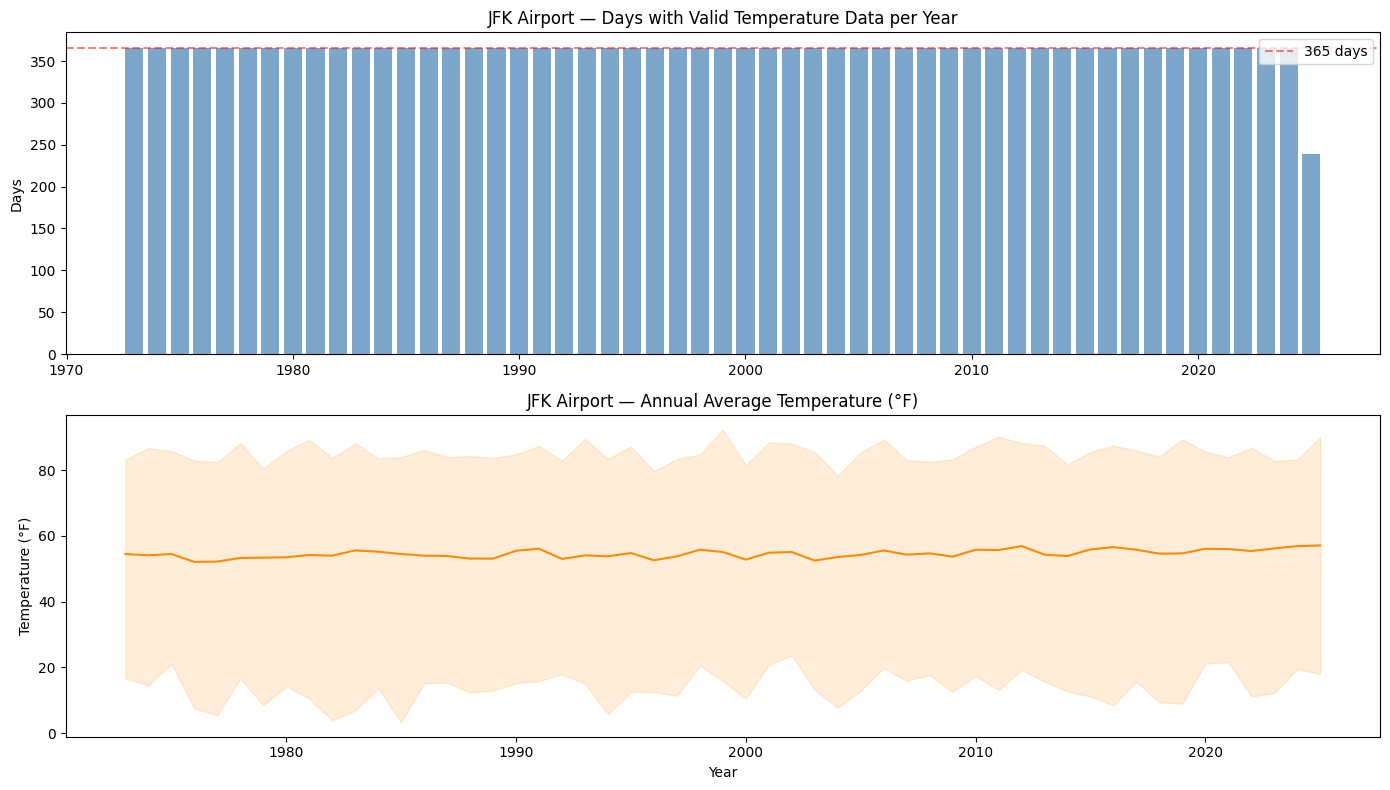

In [12]:
# Visualize: yearly data availability + average temperature trend
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Data availability
axes[0].bar(df_yearly["year"], df_yearly["valid_temp_days"], color="steelblue", alpha=0.7)
axes[0].axhline(y=365, color="red", linestyle="--", alpha=0.5, label="365 days")
axes[0].set_title("JFK Airport — Days with Valid Temperature Data per Year")
axes[0].set_ylabel("Days")
axes[0].legend()

# Average temperature trend
axes[1].plot(df_yearly["year"], df_yearly["avg_temp_f"], color="darkorange", linewidth=1.5)
axes[1].fill_between(df_yearly["year"], df_yearly["min_temp_f"], df_yearly["max_temp_f"],
                     alpha=0.15, color="darkorange")
axes[1].set_title("JFK Airport — Annual Average Temperature (°F)")
axes[1].set_ylabel("Temperature (°F)")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()

## 1.4 — Query and Clean JFK Daily Data

We'll use data from **2000–2024** to keep things manageable while having enough history for the models to learn seasonal patterns. This gives us ~25 years of daily data.

**Cleaning steps:**
1. Filter out missing values (9999.9 indicators)
2. Handle any remaining gaps (interpolation for short gaps)
3. Create a proper date column

In [13]:
# Query JFK daily temperature data: 2000-2024
query_jfk = f"""
SELECT
    PARSE_DATE('%Y%m%d', CONCAT(year, mo, da)) AS date,
    CAST(year AS INT64) AS year,
    CAST(mo AS INT64) AS month,
    CAST(da AS INT64) AS day,
    -- Temperature fields (filter 9999.9 missing indicators)
    CASE WHEN temp < 9999 THEN temp END AS temp,
    CASE WHEN max < 9999 THEN max END AS temp_max,
    CASE WHEN min < 9999 THEN min END AS temp_min,
    -- Additional weather features
    CASE WHEN dewp < 9999 THEN dewp END AS dewpoint,
    CASE WHEN slp < 9999.9 THEN slp END AS sea_level_pressure,
    CASE WHEN SAFE_CAST(wdsp AS FLOAT64) < 999.9 THEN SAFE_CAST(wdsp AS FLOAT64) END AS wind_speed,
    CASE WHEN prcp < 99.99 THEN prcp END AS precipitation,
    -- Weather condition flags
    fog,
    rain_drizzle,
    snow_ice_pellets,
    thunder
FROM
    `bigquery-public-data.noaa_gsod.gsod*`
WHERE
    stn = '{JFK_USAF}'
    AND wban = '{JFK_WBAN}'
    AND CAST(year AS INT64) BETWEEN 2000 AND 2024
ORDER BY
    date
"""

df_raw = bq_client.query(query_jfk).to_dataframe()
print(f"📊 Raw data shape: {df_raw.shape}")
print(f"📅 Date range: {df_raw['date'].min()} to {df_raw['date'].max()}")
print(f"\n🔍 Missing values:")
print(df_raw.isnull().sum())
print(f"\n📋 First few rows:")
df_raw.head()

/Users/james.carty/Documents/VScode/google-ml-engineer/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


📊 Raw data shape: (9132, 15)
📅 Date range: 2000-01-01 to 2024-12-31

🔍 Missing values:
date                  0
year                  0
month                 0
day                   0
temp                  0
temp_max              0
temp_min              0
dewpoint              0
sea_level_pressure    7
wind_speed            0
precipitation         4
fog                   0
rain_drizzle          0
snow_ice_pellets      0
thunder               0
dtype: int64

📋 First few rows:


,date,year,month,day,temp,temp_max,temp_min,dewpoint,sea_level_pressure,wind_speed,precipitation,fog,rain_drizzle,snow_ice_pellets,thunder
0,2000-01-01,2000,1,1,36.8,46.0,30.2,35.5,1023.8,6.5,0.01,1,0,0,0
1,2000-01-02,2000,1,2,44.5,54.0,31.1,42.1,1022.0,4.9,0.00,1,0,0,0
2,2000-01-03,2000,1,3,51.2,60.1,37.0,44.6,1017.4,5.4,0.00,0,0,0,0
3,2000-01-04,2000,1,4,50.9,66.0,46.0,48.1,1011.1,10.3,0.14,1,1,0,0
4,2000-01-05,2000,1,5,41.4,55.0,33.1,28.9,1013.0,15.5,0.66,1,1,0,0


In [14]:
# Check for date gaps (missing days entirely)
date_range = pd.date_range(start=df_raw["date"].min(), end=df_raw["date"].max(), freq="D")
missing_dates = set(date_range) - set(pd.to_datetime(df_raw["date"]))

print(f"📅 Expected days: {len(date_range)}")
print(f"📅 Actual days: {len(df_raw)}")
print(f"📅 Missing days: {len(missing_dates)}")

if len(missing_dates) > 0 and len(missing_dates) < 20:
    print(f"\n🔍 Missing dates:")
    for d in sorted(missing_dates)[:20]:
        print(f"   {d.strftime('%Y-%m-%d')}")

📅 Expected days: 9132
📅 Actual days: 9132
📅 Missing days: 0


In [15]:
# Clean the data:
# 1. Reindex to fill any missing dates
# 2. Interpolate short gaps (up to 3 days)
# 3. Drop rows where temp is still missing after interpolation

df = df_raw.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

# Reindex to full date range
df = df.reindex(date_range)
df.index.name = "date"

# Rebuild year/month/day from the index
df["year"] = df.index.year
df["month"] = df.index.month
df["day"] = df.index.day

# Interpolate temperature columns (linear, max 3 days gap)
temp_cols = ["temp", "temp_max", "temp_min", "dewpoint", "sea_level_pressure", "wind_speed"]
for col in temp_cols:
    df[col] = df[col].interpolate(method="linear", limit=3)

# Fill weather flags with 0 (no event) for missing days
flag_cols = ["fog", "rain_drizzle", "snow_ice_pellets", "thunder"]
for col in flag_cols:
    df[col] = df[col].fillna(0).astype(int)

# Fill precipitation with 0 for missing days
df["precipitation"] = df["precipitation"].fillna(0)

# Drop any rows still missing temp after interpolation
before_drop = len(df)
df = df.dropna(subset=["temp"])
after_drop = len(df)

print(f"✅ After cleaning:")
print(f"   Rows before: {before_drop}")
print(f"   Rows after: {after_drop}")
print(f"   Dropped: {before_drop - after_drop}")
print(f"   Remaining nulls: {df[temp_cols].isnull().sum().sum()}")
print(f"\n📋 Data sample:")
df.head()

✅ After cleaning:
   Rows before: 9132
   Rows after: 9132
   Dropped: 0
   Remaining nulls: 4

📋 Data sample:


,year,month,day,temp,temp_max,temp_min,dewpoint,sea_level_pressure,wind_speed,precipitation,fog,rain_drizzle,snow_ice_pellets,thunder
date,,,,,,,,,,,,,,
2000-01-01,2000,1,1,36.8,46.0,30.2,35.5,1023.8,6.5,0.01,1,0,0,0
2000-01-02,2000,1,2,44.5,54.0,31.1,42.1,1022.0,4.9,0.00,1,0,0,0
2000-01-03,2000,1,3,51.2,60.1,37.0,44.6,1017.4,5.4,0.00,0,0,0,0
2000-01-04,2000,1,4,50.9,66.0,46.0,48.1,1011.1,10.3,0.14,1,1,0,0
2000-01-05,2000,1,5,41.4,55.0,33.1,28.9,1013.0,15.5,0.66,1,1,0,0


## 1.5 — Temporal Feature Engineering

This is the key new skill in this lab. Unlike census data where features are independent observations, time series data has **temporal structure** — what happened yesterday matters for predicting today.

**Feature categories:**

1. **Calendar features:** month, day_of_week, day_of_year (captures seasonality)
2. **Cyclical encoding:** sin/cos transforms for periodic features (so December and January are "close" to each other, not 12 apart)
3. **Lag features:** yesterday's temp, temp 7 days ago, temp 30 days ago
4. **Rolling statistics:** 7-day moving average, 30-day moving average, 7-day std dev
5. **Year-over-year:** same day last year

**Why cyclical encoding?**

If we use raw month numbers (1-12), the model thinks December (12) is far from January (1). But in reality they're adjacent! Sin/cos encoding maps them to a circle:
- `sin(2π × month/12)` and `cos(2π × month/12)`
- January and December end up close together on the unit circle

This is a very common exam topic.

In [16]:
# ── Temporal Feature Engineering ──────────────────────────

# Calendar features
df["day_of_week"] = df.index.dayofweek      # 0=Monday, 6=Sunday
df["day_of_year"] = df.index.dayofyear       # 1-366
df["week_of_year"] = df.index.isocalendar().week.astype(int)

# Cyclical encoding for periodic features
# This ensures Dec (12) and Jan (1) are close, not 11 apart
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

# Lag features — what happened recently?
for lag in [1, 2, 3, 7, 14, 30, 365]:
    df[f"temp_lag_{lag}"] = df["temp"].shift(lag)

# Rolling statistics — smoothed trends
for window in [7, 14, 30]:
    df[f"temp_rolling_mean_{window}"] = df["temp"].shift(1).rolling(window=window).mean()
    df[f"temp_rolling_std_{window}"] = df["temp"].shift(1).rolling(window=window).std()

# Temperature range (daily spread)
df["temp_range"] = df["temp_max"] - df["temp_min"]

print(f"✅ Feature engineering complete")
print(f"   Total features: {len(df.columns)}")
print(f"   New features: {len(df.columns) - len(df_raw.columns)}")
print(f"\n📋 Feature list:")
for col in sorted(df.columns):
    print(f"   {col}")

✅ Feature engineering complete
   Total features: 37
   New features: 22

📋 Feature list:
   day
   day_of_week
   day_of_year
   dewpoint
   dow_cos
   dow_sin
   doy_cos
   doy_sin
   fog
   month
   month_cos
   month_sin
   precipitation
   rain_drizzle
   sea_level_pressure
   snow_ice_pellets
   temp
   temp_lag_1
   temp_lag_14
   temp_lag_2
   temp_lag_3
   temp_lag_30
   temp_lag_365
   temp_lag_7
   temp_max
   temp_min
   temp_range
   temp_rolling_mean_14
   temp_rolling_mean_30
   temp_rolling_mean_7
   temp_rolling_std_14
   temp_rolling_std_30
   temp_rolling_std_7
   thunder
   week_of_year
   wind_speed
   year


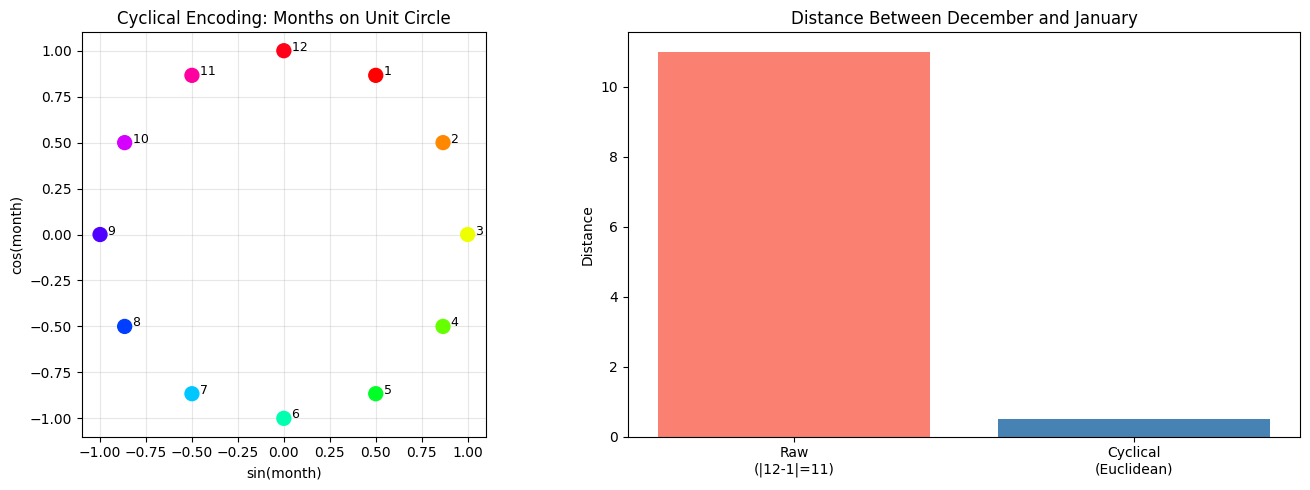

💡 Cyclical encoding makes Dec→Jan distance small, reflecting reality.


In [17]:
# Visualize cyclical encoding to make sure it looks right
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Month cyclical encoding
months = np.arange(1, 13)
sin_vals = np.sin(2 * np.pi * months / 12)
cos_vals = np.cos(2 * np.pi * months / 12)

axes[0].scatter(sin_vals, cos_vals, c=months, cmap="hsv", s=100, zorder=5)
for m, s, c in zip(months, sin_vals, cos_vals):
    axes[0].annotate(f"  {m}", (s, c), fontsize=9)
axes[0].set_title("Cyclical Encoding: Months on Unit Circle")
axes[0].set_xlabel("sin(month)")
axes[0].set_ylabel("cos(month)")
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.3)

# Show why it matters: distance between Dec and Jan
axes[1].bar(["Raw\n(|12-1|=11)", "Cyclical\n(Euclidean)"], [11, 
    np.sqrt((sin_vals[11]-sin_vals[0])**2 + (cos_vals[11]-cos_vals[0])**2)],
    color=["salmon", "steelblue"])
axes[1].set_title("Distance Between December and January")
axes[1].set_ylabel("Distance")

plt.tight_layout()
plt.show()
print("💡 Cyclical encoding makes Dec→Jan distance small, reflecting reality.")

## 1.6 — Time-Aware Train/Val/Test Split

**Critical concept:** You cannot randomly split time series data! Random splitting causes **data leakage** — the model sees future data during training.

**Correct approach:** Split chronologically.
- **Train:** 2000–2020 (21 years)
- **Validation:** 2021–2022 (2 years)
- **Test:** 2023–2024 (2 years)

This simulates a real production scenario: train on historical data, validate on recent data, test on the most recent period.

In [18]:
# Drop rows with NaN from lag/rolling features (first ~365 rows)
df_features = df.dropna().copy()
print(f"📊 After dropping NaN from lag features: {len(df_features)} rows")
print(f"   Date range: {df_features.index.min().date()} to {df_features.index.max().date()}")

# ── Time-aware split ────────────────────────────────────
TRAIN_END = "2020-12-31"
VAL_END = "2022-12-31"
# Test = everything after 2022-12-31

df_train = df_features.loc[:TRAIN_END].copy()
df_val = df_features.loc[TRAIN_END:VAL_END].iloc[1:].copy()  # Exclude the boundary date
df_test = df_features.loc[VAL_END:].iloc[1:].copy()

print(f"\n📊 Split sizes:")
print(f"   Train: {len(df_train)} rows ({df_train.index.min().date()} → {df_train.index.max().date()})")
print(f"   Val:   {len(df_val)} rows ({df_val.index.min().date()} → {df_val.index.max().date()})")
print(f"   Test:  {len(df_test)} rows ({df_test.index.min().date()} → {df_test.index.max().date()})")

# Sanity check: no overlap
assert df_train.index.max() < df_val.index.min(), "Train/val overlap!"
assert df_val.index.max() < df_test.index.min(), "Val/test overlap!"
print("\n✅ No overlap between splits — no data leakage")

📊 After dropping NaN from lag features: 8763 rows
   Date range: 2000-12-31 to 2024-12-31

📊 Split sizes:
   Train: 7302 rows (2000-12-31 → 2020-12-31)
   Val:   730 rows (2021-01-01 → 2022-12-31)
   Test:  731 rows (2023-01-01 → 2024-12-31)

✅ No overlap between splits — no data leakage


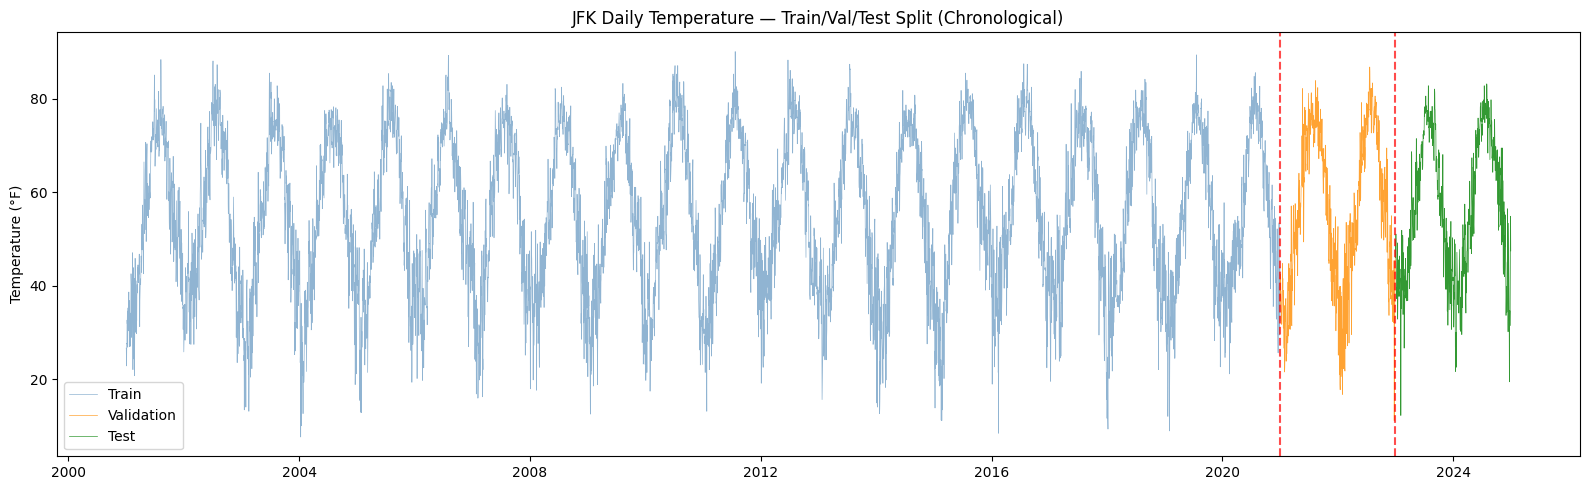

In [19]:
# Visualize the splits
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df_train.index, df_train["temp"], color="steelblue", alpha=0.6, linewidth=0.5, label="Train")
ax.plot(df_val.index, df_val["temp"], color="darkorange", alpha=0.8, linewidth=0.5, label="Validation")
ax.plot(df_test.index, df_test["temp"], color="green", alpha=0.8, linewidth=0.5, label="Test")

# Add split boundaries
ax.axvline(pd.Timestamp(TRAIN_END), color="red", linestyle="--", alpha=0.7)
ax.axvline(pd.Timestamp(VAL_END), color="red", linestyle="--", alpha=0.7)

ax.set_title("JFK Daily Temperature — Train/Val/Test Split (Chronological)")
ax.set_ylabel("Temperature (°F)")
ax.legend()
plt.tight_layout()
plt.show()

## 1.7 — Export Data to GCS

Export the cleaned, feature-engineered data for use by custom training jobs.

In [20]:
# Save train/val/test to local CSV files
for split_name, split_df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    export_df = split_df.reset_index()
    export_df["date"] = export_df["date"].astype(str)
    
    local_path = f"/tmp/jfk_weather_{split_name}.csv"
    export_df.to_csv(local_path, index=False)
    
    print(f"✅ {split_name}: {len(split_df)} rows → {local_path}")

print(f"\n📋 Columns exported: {list(df_train.reset_index().columns)}")

✅ train: 7302 rows → /tmp/jfk_weather_train.csv
✅ val: 730 rows → /tmp/jfk_weather_val.csv
✅ test: 731 rows → /tmp/jfk_weather_test.csv

📋 Columns exported: ['date', 'year', 'month', 'day', 'temp', 'temp_max', 'temp_min', 'dewpoint', 'sea_level_pressure', 'wind_speed', 'precipitation', 'fog', 'rain_drizzle', 'snow_ice_pellets', 'thunder', 'day_of_week', 'day_of_year', 'week_of_year', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'temp_lag_1', 'temp_lag_2', 'temp_lag_3', 'temp_lag_7', 'temp_lag_14', 'temp_lag_30', 'temp_lag_365', 'temp_rolling_mean_7', 'temp_rolling_std_7', 'temp_rolling_mean_14', 'temp_rolling_std_14', 'temp_rolling_mean_30', 'temp_rolling_std_30', 'temp_range']


In [21]:
# Upload local CSV files to GCS
for split_name in ["train", "val", "test"]:
    local_path = f"/tmp/jfk_weather_{split_name}.csv"
    gcs_path = f"{LAB9_PREFIX}/data/jfk_weather_{split_name}.csv"
    
    blob = bucket.blob(gcs_path)
    blob.upload_from_filename(local_path)
    
    print(f"✅ Uploaded → gs://{BUCKET_NAME}/{gcs_path}")

✅ Uploaded → gs://carty-470812-time-series/lab9-timeseries/data/jfk_weather_train.csv
✅ Uploaded → gs://carty-470812-time-series/lab9-timeseries/data/jfk_weather_val.csv
✅ Uploaded → gs://carty-470812-time-series/lab9-timeseries/data/jfk_weather_test.csv


## 1.8 — Save Clean Data to BigQuery

We also need the clean data in BigQuery for ARIMA_PLUS (Part 2) and ML.PREDICT (Part 5).

In [22]:
# Save the full cleaned dataset (without engineered features) to BigQuery
# ARIMA_PLUS only needs date + temp — it handles its own feature engineering
df_bq = df[["temp"]].copy()
df_bq = df_bq.dropna()
df_bq = df_bq.reset_index()
df_bq.columns = ["date", "temp"]

table_id = f"{PROJECT_ID}.{BQ_DATASET}.jfk_daily_temp"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    schema=[
        bigquery.SchemaField("date", "DATE"),
        bigquery.SchemaField("temp", "FLOAT64"),
    ],
)

job = bq_client.load_table_from_dataframe(df_bq, table_id, job_config=job_config)
job.result()

print(f"✅ Loaded {len(df_bq)} rows to {table_id}")

# Also save the full feature-engineered dataset for ML.PREDICT later
df_full_features = df_features.reset_index()
df_full_features["date"] = df_full_features["date"].astype(str)
table_id_features = f"{PROJECT_ID}.{BQ_DATASET}.jfk_daily_features"

job = bq_client.load_table_from_dataframe(
    df_full_features, table_id_features,
    job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
)
job.result()
print(f"✅ Loaded {len(df_full_features)} rows to {table_id_features}")

/Users/james.carty/Documents/VScode/google-ml-engineer/.venv/lib/python3.13/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


✅ Loaded 9132 rows to carty-470812.lab9_timeseries.jfk_daily_temp


/Users/james.carty/Documents/VScode/google-ml-engineer/.venv/lib/python3.13/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


✅ Loaded 8763 rows to carty-470812.lab9_timeseries.jfk_daily_features


---

**Part 1 Complete!** ✅

**What you built:**
- Queried and cleaned 25 years of JFK weather data from NOAA GSOD
- Handled missing value indicators (9999.9), date gaps, and interpolation
- Engineered temporal features: cyclical encoding, lag features, rolling statistics
- Created chronological train/val/test split (no data leakage!)
- Exported to both GCS (CSV) and BigQuery

**Key takeaways:**
- Time series data requires chronological splitting — random splits cause data leakage
- Cyclical encoding (sin/cos) is essential for periodic features
- Lag and rolling features capture temporal dependencies
- NOAA GSOD uses 9999.9 as missing value indicator — always check raw data conventions

---

# Part 2: BigQuery ML ARIMA_PLUS

## Why ARIMA_PLUS?

ARIMA_PLUS is BigQuery ML's time series forecasting model. It's an enhanced ARIMA that automatically handles:
- **Trend** (long-term direction)
- **Seasonality** (repeating patterns — daily, weekly, yearly)
- **Holiday effects** (if configured)
- **Spike and dip detection**

**Exam relevance:** ARIMA_PLUS is a common correct answer for "SQL user needs time series forecasting with minimal ML expertise." It runs entirely in BigQuery — no containers, no Vertex AI, no Python. The exam loves asking when to use BQML vs custom.

**Key BQML functions we'll use:**
- `CREATE MODEL` — train the ARIMA_PLUS model
- `ML.FORECAST` — generate future predictions with confidence intervals
- `ML.EXPLAIN_FORECAST` — decompose into trend + seasonal + residual
- `ML.EVALUATE` — get model metrics

## 2.1 — Train ARIMA_PLUS Model

In [23]:
# Train ARIMA_PLUS on the training data (2000-2020)
# ARIMA_PLUS only needs two columns: a timestamp and the target value
# It automatically detects seasonality, trend, and handles decomposition

query_train_arima = f"""
CREATE OR REPLACE MODEL `{BQ_DATASET}.jfk_temp_arima`
OPTIONS(
    model_type = 'ARIMA_PLUS',
    time_series_timestamp_col = 'date',
    time_series_data_col = 'temp',
    auto_arima = TRUE,
    data_frequency = 'DAILY',
    holiday_region = 'US',
    horizon = 1461
) AS
SELECT
    date,
    temp
FROM
    `{BQ_DATASET}.jfk_daily_temp`
WHERE
    date <= '2020-12-31'
"""

print("⏳ Training ARIMA_PLUS model (this may take 1-2 minutes)...")
job = bq_client.query(query_train_arima)
job.result()
print("✅ ARIMA_PLUS model trained!")

⏳ Training ARIMA_PLUS model (this may take 1-2 minutes)...
✅ ARIMA_PLUS model trained!


## 2.2 — Evaluate the Model

In [24]:
# Get model evaluation metrics
query_eval = f"""
SELECT *
FROM ML.EVALUATE(MODEL `{BQ_DATASET}.jfk_temp_arima`)
"""

df_eval = bq_client.query(query_eval).to_dataframe()
print("📊 ARIMA_PLUS Model Evaluation:")
print(df_eval.to_string(index=False))

📊 ARIMA_PLUS Model Evaluation:
 non_seasonal_p  non_seasonal_d  non_seasonal_q  has_drift  log_likelihood          AIC  variance seasonal_periods  has_holiday_effect  has_spikes_and_dips  has_step_changes
              1               1               1      False   -19949.806937 39905.613875 10.631961 [WEEKLY, YEARLY]                True                 True             False
              1               1               1       True   -19949.776234 39907.552468 10.631870 [WEEKLY, YEARLY]                True                 True             False
              0               1               2      False   -20086.746473 40179.492947 11.021268 [WEEKLY, YEARLY]                True                 True             False
              0               1               2       True   -20086.747050 40181.494100 11.021269 [WEEKLY, YEARLY]                True                 True             False
              2               1               0      False   -20160.942184 40327.884367 11.236776 [

/Users/james.carty/Documents/VScode/google-ml-engineer/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [25]:
# Check the ARIMA coefficients and detected parameters
query_arima_info = f"""
SELECT *
FROM ML.ARIMA_COEFFICIENTS(MODEL `{BQ_DATASET}.jfk_temp_arima`)
"""

df_arima = bq_client.query(query_arima_info).to_dataframe()
print("📊 ARIMA Coefficients (auto-selected):")
print(df_arima.to_string(index=False))

📊 ARIMA Coefficients (auto-selected):
     ar_coefficients       ma_coefficients  intercept_or_drift
[0.7266757271347261] [-0.9912717530694455]                 0.0


/Users/james.carty/Documents/VScode/google-ml-engineer/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


## 2.3 — Forecast with ML.FORECAST

ML.FORECAST generates future predictions with confidence intervals. Let's forecast the validation + test period (2021–2024) so we can compare against actuals.

In [26]:
# Forecast 4 years ahead (validation + test period)
# ~1461 days from 2021-01-01 to 2024-12-31
FORECAST_HORIZON = 1461

query_forecast = f"""
SELECT
    forecast_timestamp AS date,
    forecast_value AS predicted_temp,
    standard_error,
    confidence_level,
    prediction_interval_lower_bound AS lower_bound,
    prediction_interval_upper_bound AS upper_bound
FROM
    ML.FORECAST(MODEL `{BQ_DATASET}.jfk_temp_arima`,
                STRUCT({FORECAST_HORIZON} AS horizon,
                       0.95 AS confidence_level))
ORDER BY
    forecast_timestamp
"""

df_forecast = bq_client.query(query_forecast).to_dataframe()
df_forecast["date"] = pd.to_datetime(df_forecast["date"])

print(f"📊 Forecast shape: {df_forecast.shape}")
print(f"📅 Forecast range: {df_forecast['date'].min().date()} to {df_forecast['date'].max().date()}")
df_forecast.head(10)

/Users/james.carty/Documents/VScode/google-ml-engineer/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


📊 Forecast shape: (1461, 6)
📅 Forecast range: 2021-01-01 to 2024-12-31


,date,predicted_temp,standard_error,confidence_level,lower_bound,upper_bound
0,2021-01-01 00:00:00+00:00,39.633840,3.260669,0.95,33.254478,46.013202
1,2021-01-02 00:00:00+00:00,37.233630,4.047459,0.95,29.314945,45.152314
2,2021-01-03 00:00:00+00:00,35.497241,4.417945,0.95,26.853718,44.140764
3,2021-01-04 00:00:00+00:00,33.144245,4.609604,0.95,24.125749,42.162741
4,2021-01-05 00:00:00+00:00,30.581707,4.713525,0.95,21.359894,39.803520
5,2021-01-06 00:00:00+00:00,24.568084,4.771840,0.95,15.232180,33.903989
6,2021-01-07 00:00:00+00:00,34.691227,4.805634,0.95,25.289205,44.093248
7,2021-01-08 00:00:00+00:00,38.781963,4.825906,0.95,29.340280,48.223647
8,2021-01-09 00:00:00+00:00,33.582468,4.838550,0.95,24.116048,43.048888
9,2021-01-10 00:00:00+00:00,38.969881,4.846788,0.95,29.487343,48.452420


In [27]:
# Compare forecast to actuals on the val+test period
df_actuals = df[["temp"]].loc["2021-01-01":"2024-12-31"].copy()
df_actuals = df_actuals.dropna()

# Remove timezone from forecast dates to match df_actuals
df_forecast_tz_naive = df_forecast.copy()
df_forecast_tz_naive["date"] = df_forecast_tz_naive["date"].dt.tz_localize(None)

# Merge forecasts with actuals
df_compare_arima = df_forecast_tz_naive.set_index("date").join(
    df_actuals.rename(columns={"temp": "actual_temp"}),
    how="inner"
)

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_arima = np.sqrt(mean_squared_error(df_compare_arima["actual_temp"], df_compare_arima["predicted_temp"]))
mae_arima = mean_absolute_error(df_compare_arima["actual_temp"], df_compare_arima["predicted_temp"])
mape_arima = np.mean(np.abs(
    (df_compare_arima["actual_temp"] - df_compare_arima["predicted_temp"]) / df_compare_arima["actual_temp"]
)) * 100

print("📊 ARIMA_PLUS Performance (Val + Test period):")
print(f"   RMSE: {rmse_arima:.2f} °F")
print(f"   MAE:  {mae_arima:.2f} °F")
print(f"   MAPE: {mape_arima:.1f}%")

📊 ARIMA_PLUS Performance (Val + Test period):
   RMSE: 7.10 °F
   MAE:  5.53 °F
   MAPE: 11.9%


In [28]:
# Split metrics: validation vs test separately
df_val_arima = df_compare_arima.loc[:"2022-12-31"]
df_test_arima = df_compare_arima.loc["2023-01-01":]

for name, subset in [("Validation (2021-2022)", df_val_arima), ("Test (2023-2024)", df_test_arima)]:
    rmse = np.sqrt(mean_squared_error(subset["actual_temp"], subset["predicted_temp"]))
    mae = mean_absolute_error(subset["actual_temp"], subset["predicted_temp"])
    print(f"\n📊 {name}:")
    print(f"   RMSE: {rmse:.2f} °F")
    print(f"   MAE:  {mae:.2f} °F")
    print(f"   Rows: {len(subset)}")


📊 Validation (2021-2022):
   RMSE: 7.13 °F
   MAE:  5.60 °F
   Rows: 730

📊 Test (2023-2024):
   RMSE: 7.07 °F
   MAE:  5.46 °F
   Rows: 731


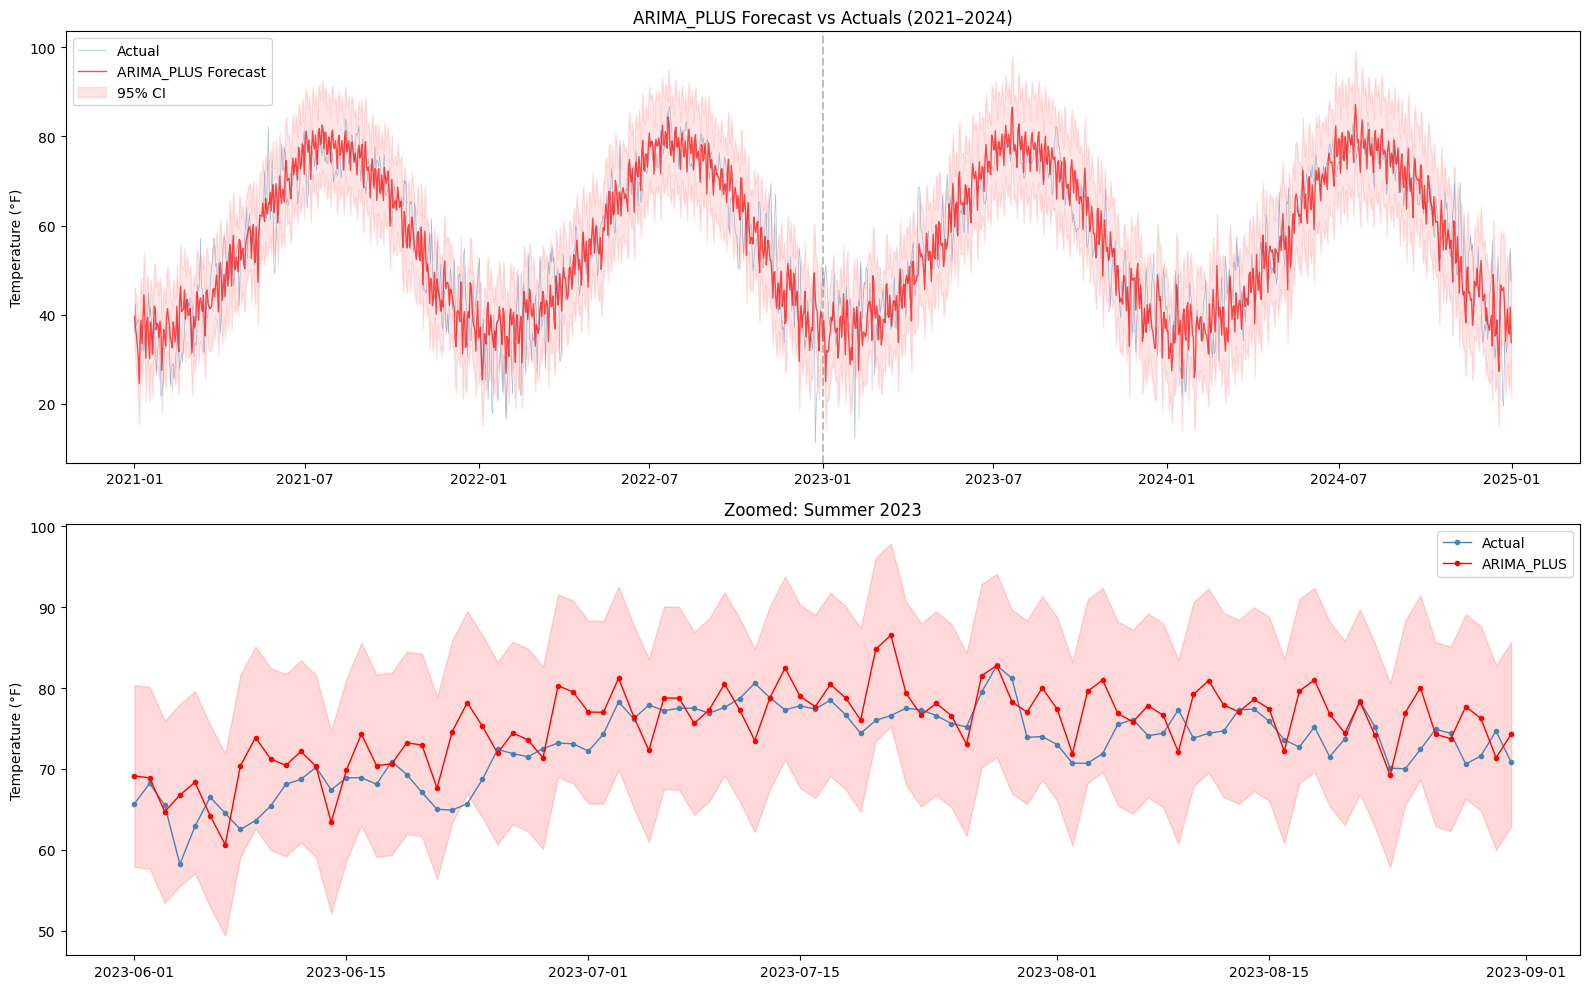

In [29]:
# Visualize forecast vs actuals
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Full view
axes[0].plot(df_compare_arima.index, df_compare_arima["actual_temp"], 
             color="steelblue", alpha=0.5, linewidth=0.5, label="Actual")
axes[0].plot(df_compare_arima.index, df_compare_arima["predicted_temp"],
             color="red", alpha=0.7, linewidth=1, label="ARIMA_PLUS Forecast")
axes[0].fill_between(df_compare_arima.index, 
                     df_compare_arima["lower_bound"], df_compare_arima["upper_bound"],
                     alpha=0.1, color="red", label="95% CI")
axes[0].axvline(pd.Timestamp("2023-01-01"), color="gray", linestyle="--", alpha=0.5)
axes[0].set_title("ARIMA_PLUS Forecast vs Actuals (2021–2024)")
axes[0].set_ylabel("Temperature (°F)")
axes[0].legend()

# Zoomed: 3 months
zoom_start, zoom_end = "2023-06-01", "2023-08-31"
zoom = df_compare_arima.loc[zoom_start:zoom_end]
axes[1].plot(zoom.index, zoom["actual_temp"], "o-", color="steelblue", 
             markersize=3, linewidth=1, label="Actual")
axes[1].plot(zoom.index, zoom["predicted_temp"], "o-", color="red",
             markersize=3, linewidth=1, label="ARIMA_PLUS")
axes[1].fill_between(zoom.index, zoom["lower_bound"], zoom["upper_bound"],
                     alpha=0.15, color="red")
axes[1].set_title("Zoomed: Summer 2023")
axes[1].set_ylabel("Temperature (°F)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 2.4 — Explain the Forecast with ML.EXPLAIN_FORECAST

ML.EXPLAIN_FORECAST decomposes the forecast into its components: trend, seasonal patterns, and holiday effects. This is valuable for understanding *why* the model makes certain predictions.

In [30]:
# Discover actual column names
query_check = f"""
SELECT *
FROM ML.EXPLAIN_FORECAST(MODEL `{BQ_DATASET}.jfk_temp_arima`,
                         STRUCT({FORECAST_HORIZON} AS horizon))
LIMIT 5
"""
df_check = bq_client.query(query_check).to_dataframe()
print("Columns:", df_check.columns.tolist())
df_check

Columns: ['time_series_timestamp', 'time_series_type', 'time_series_data', 'time_series_adjusted_data', 'standard_error', 'confidence_level', 'prediction_interval_lower_bound', 'prediction_interval_upper_bound', 'trend', 'seasonal_period_yearly', 'seasonal_period_quarterly', 'seasonal_period_monthly', 'seasonal_period_weekly', 'seasonal_period_daily', 'holiday_effect', 'spikes_and_dips', 'step_changes', 'residual', 'holiday_effect_Christmas', 'holiday_effect_EasterMonday', 'holiday_effect_Halloween', 'holiday_effect_MardiGras', 'holiday_effect_MothersDay', 'holiday_effect_NewYear', 'holiday_effect_StPatrickDay', 'holiday_effect_US_ColumbusDay', 'holiday_effect_US_DaylightSavingEnd', 'holiday_effect_US_DaylightSavingStart', 'holiday_effect_US_ElectionDay', 'holiday_effect_US_IndependenceDay', 'holiday_effect_US_LaborDay', 'holiday_effect_US_MLKDay', 'holiday_effect_US_MemorialDay', 'holiday_effect_US_PresidentDay', 'holiday_effect_US_Superbowl', 'holiday_effect_US_Thanksgiving', 'holida

/Users/james.carty/Documents/VScode/google-ml-engineer/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,time_series_timestamp,time_series_type,time_series_data,time_series_adjusted_data,standard_error,confidence_level,prediction_interval_lower_bound,prediction_interval_upper_bound,trend,seasonal_period_yearly,...,holiday_effect_US_ElectionDay,holiday_effect_US_IndependenceDay,holiday_effect_US_LaborDay,holiday_effect_US_MLKDay,holiday_effect_US_MemorialDay,holiday_effect_US_PresidentDay,holiday_effect_US_Superbowl,holiday_effect_US_Thanksgiving,holiday_effect_Valentine,holiday_effect_VeteranDay
0,2000-01-01 00:00:00+00:00,history,36.8,36.800000,3.260669,NaN,NaN,NaN,0.000000,-19.670070,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2000-01-02 00:00:00+00:00,history,44.5,46.002378,3.260669,NaN,NaN,NaN,62.046926,-18.635871,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2000-01-03 00:00:00+00:00,history,51.2,46.684189,3.260669,NaN,NaN,NaN,60.749677,-18.624835,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2000-01-04 00:00:00+00:00,history,50.9,49.420004,3.260669,NaN,NaN,NaN,64.723902,-18.690160,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2000-01-05 00:00:00+00:00,history,41.4,48.151245,3.260669,NaN,NaN,NaN,65.564937,-18.886962,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [31]:
# Decompose the forecast into components
query_explain = f"""
SELECT
    time_series_timestamp AS date,
    time_series_type,
    time_series_data AS value,
    time_series_adjusted_data AS adjusted_value,
    trend,
    seasonal_period_yearly,
    seasonal_period_weekly,
    holiday_effect,
    residual
FROM
    ML.EXPLAIN_FORECAST(MODEL `{BQ_DATASET}.jfk_temp_arima`,
                        STRUCT({FORECAST_HORIZON} AS horizon))
ORDER BY
    time_series_timestamp
"""

df_explain = bq_client.query(query_explain).to_dataframe()
df_explain["date"] = pd.to_datetime(df_explain["date"]).dt.tz_localize(None)  # Remove timezone
print(f"📊 Explanation shape: {df_explain.shape}")
print(f"📋 Time series types: {df_explain['time_series_type'].unique()}")
df_explain.head(10)

/Users/james.carty/Documents/VScode/google-ml-engineer/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


📊 Explanation shape: (9132, 9)
📋 Time series types: ['history' 'forecast']


,date,time_series_type,value,adjusted_value,trend,seasonal_period_yearly,seasonal_period_weekly,holiday_effect,residual
0,2000-01-01,history,36.8,36.800000,0.000000,-19.670070,-5.576866,0.0,62.046936
1,2000-01-02,history,44.5,46.002378,62.046926,-18.635871,2.591323,0.0,-1.502378
2,2000-01-03,history,51.2,46.684189,60.749677,-18.624835,4.559347,0.0,4.515811
3,2000-01-04,history,50.9,49.420004,64.723902,-18.690160,3.386262,0.0,1.479996
4,2000-01-05,history,41.4,48.151245,65.564937,-18.886962,1.473269,0.0,-6.751245
5,2000-01-06,history,32.2,36.839082,59.538861,-21.126140,-1.573639,0.0,-4.639082
6,2000-01-07,history,40.6,34.585894,56.283692,-16.907119,-4.790679,0.0,6.014106
7,2000-01-08,history,34.9,36.836557,62.149525,-19.840869,-5.472099,0.0,-1.936557
8,2000-01-09,history,40.7,42.667281,60.488543,-20.336146,2.514884,0.0,-1.967281
9,2000-01-10,history,45.9,45.960776,59.121184,-17.701157,4.540749,0.0,-0.060776


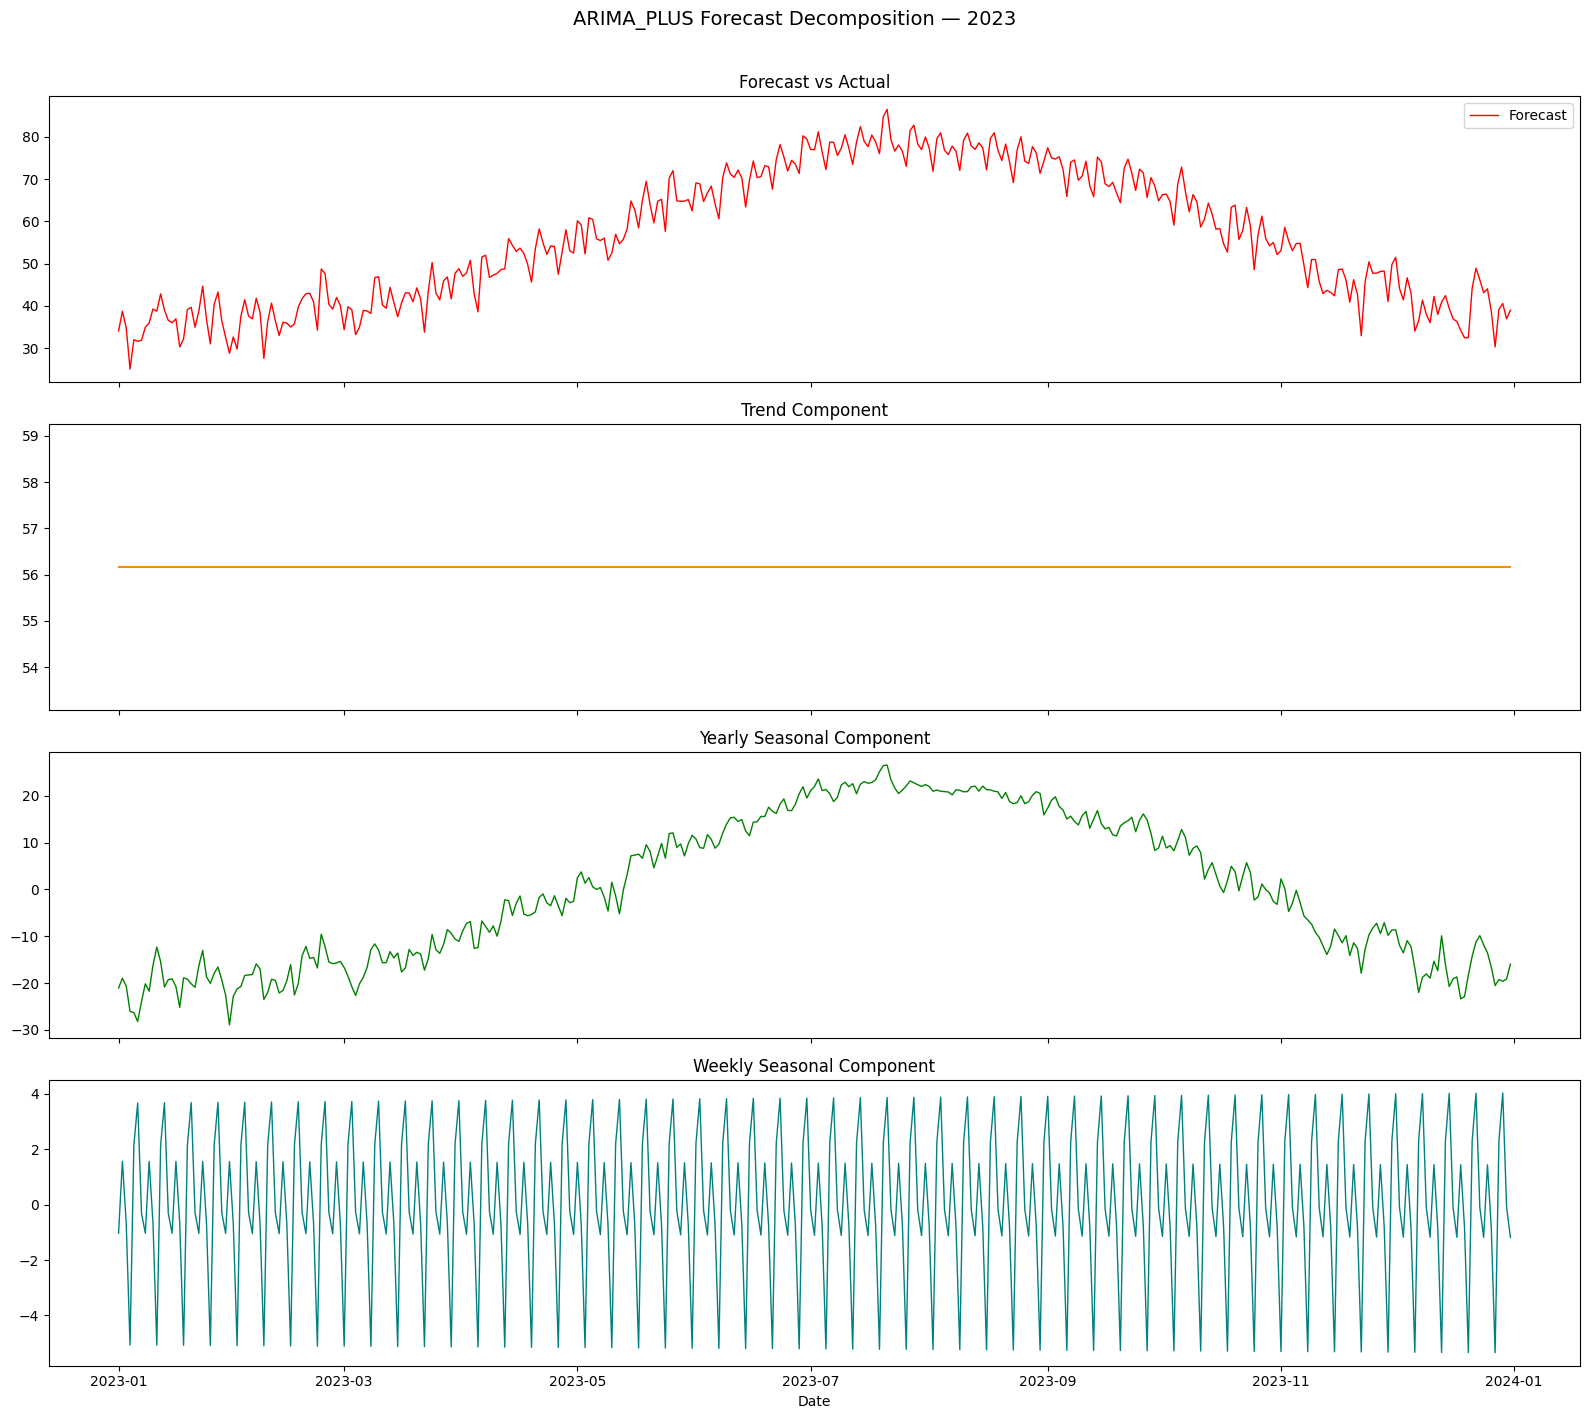

💡 The yearly seasonal component should show the classic temperature sine wave.
   Trend captures any long-term warming/cooling. Holiday effects are typically small for temperature.


In [32]:
# Visualize the decomposition
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

# Use a 1-year window for clarity
decomp = df_explain.set_index("date").loc["2023-01-01":"2023-12-31"]

# Filter forecast vs history
decomp_forecast = decomp[decomp["time_series_type"] == "forecast"]
decomp_history = decomp[decomp["time_series_type"] == "history"]

# Plot 1: Forecast/Actual values
axes[0].plot(decomp_forecast.index, decomp_forecast["value"], color="red", linewidth=1, label="Forecast")
if len(decomp_history) > 0:
    axes[0].plot(decomp_history.index, decomp_history["value"], color="steelblue", alpha=0.5, linewidth=0.5, label="Actual")
axes[0].set_title("Forecast vs Actual")
axes[0].legend()

# Plot 2: Trend
axes[1].plot(decomp.index, decomp["trend"], color="darkorange", linewidth=1.5)
axes[1].set_title("Trend Component")

# Plot 3: Yearly Seasonal
axes[2].plot(decomp.index, decomp["seasonal_period_yearly"], color="green", linewidth=1)
axes[2].set_title("Yearly Seasonal Component")

# Plot 4: Holiday Effect or Weekly Seasonal
if decomp["holiday_effect"].notna().any() and decomp["holiday_effect"].abs().sum() > 0:
    axes[3].bar(decomp.index, decomp["holiday_effect"], color="purple", alpha=0.7)
    axes[3].set_title("Holiday Effect")
else:
    axes[3].plot(decomp.index, decomp["seasonal_period_weekly"], color="teal", linewidth=1)
    axes[3].set_title("Weekly Seasonal Component")

axes[3].set_xlabel("Date")

plt.suptitle("ARIMA_PLUS Forecast Decomposition — 2023", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("💡 The yearly seasonal component should show the classic temperature sine wave.")
print("   Trend captures any long-term warming/cooling. Holiday effects are typically small for temperature.")

---

**Part 2 Complete!** ✅

**What you built:**
- Trained an ARIMA_PLUS model entirely in BigQuery SQL
- Used ML.FORECAST to generate predictions with confidence intervals
- Used ML.EXPLAIN_FORECAST to decompose predictions into trend + seasonal + holiday
- Evaluated with regression metrics (RMSE, MAE, MAPE)

**Key takeaways:**
- ARIMA_PLUS is zero-code ML — SQL users can do time series forecasting without Python
- `auto_arima=TRUE` handles parameter selection automatically
- ML.EXPLAIN_FORECAST is unique to BQML — not available in custom models
- Confidence intervals widen as you forecast further out (uncertainty grows)
- For temperature, the yearly seasonal component dominates

---

# Part 3: Custom Training — Gradient Boosted Trees

## Why treat time series as tabular regression?

ARIMA_PLUS uses the time series structure directly. But there's another approach: **use lag and rolling features to convert time series into a tabular regression problem**, then use any supervised learning algorithm.

**Advantages:**
- Can incorporate external features (weather conditions, day of week, etc.)
- GBT handles non-linear relationships well
- Doesn't assume stationarity like ARIMA

**Disadvantages:**
- Requires manual feature engineering
- Doesn't naturally produce confidence intervals
- Can't forecast multiple steps ahead without recursive prediction

**Exam insight:** The exam often tests whether you know that GBT can be competitive with specialized time series models when features are well-engineered. The answer often depends on whether the scenario emphasizes "minimal effort" (→ ARIMA_PLUS) or "maximum accuracy with external features" (→ custom GBT/neural).

## 3.1 — Prepare Features for GBT

In [33]:
# Define feature columns for GBT
# We'll use all our engineered features EXCEPT the target and raw date columns

TARGET = "temp"

# Features to exclude from training
EXCLUDE_COLS = [
    "temp", "temp_max", "temp_min",  # target and highly correlated
    "year",  # raw year (we have cyclical features)
    "month", "day",  # raw (we have cyclical features)
    "day_of_week", "day_of_year", "week_of_year",  # raw (we have cyclical)
]

FEATURE_COLS = [col for col in df_train.columns if col not in EXCLUDE_COLS]

print(f"📋 Features ({len(FEATURE_COLS)}):")
for i, col in enumerate(FEATURE_COLS):
    print(f"   {i+1:2d}. {col}")

# Prepare numpy arrays
X_train = df_train[FEATURE_COLS].values
y_train = df_train[TARGET].values
X_val = df_val[FEATURE_COLS].values
y_val = df_val[TARGET].values
X_test = df_test[FEATURE_COLS].values
y_test = df_test[TARGET].values

print(f"\n📊 Shapes:")
print(f"   X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"   X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"   X_test:  {X_test.shape}, y_test:  {y_test.shape}")

📋 Features (28):
    1. dewpoint
    2. sea_level_pressure
    3. wind_speed
    4. precipitation
    5. fog
    6. rain_drizzle
    7. snow_ice_pellets
    8. thunder
    9. month_sin
   10. month_cos
   11. dow_sin
   12. dow_cos
   13. doy_sin
   14. doy_cos
   15. temp_lag_1
   16. temp_lag_2
   17. temp_lag_3
   18. temp_lag_7
   19. temp_lag_14
   20. temp_lag_30
   21. temp_lag_365
   22. temp_rolling_mean_7
   23. temp_rolling_std_7
   24. temp_rolling_mean_14
   25. temp_rolling_std_14
   26. temp_rolling_mean_30
   27. temp_rolling_std_30
   28. temp_range

📊 Shapes:
   X_train: (7302, 28), y_train: (7302,)
   X_val:   (730, 28), y_val:   (730,)
   X_test:  (731, 28), y_test:  (731,)


## 3.2 — Train GBT Locally First

Same pattern as your earlier labs — train locally to validate, then move to Vertex AI.

In [34]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import time

# Train with reasonable defaults first
print("⏳ Training Gradient Boosted Trees locally...")
start_time = time.time()

gbt = GradientBoostingRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)

gbt.fit(X_train, y_train)
train_time = time.time() - start_time

# Predictions
y_val_pred = gbt.predict(X_val)
y_test_pred = gbt.predict(X_test)

# Metrics
for name, y_true, y_pred in [("Validation", y_val, y_val_pred), ("Test", y_test, y_test_pred)]:
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n📊 GBT {name}:")
    print(f"   RMSE: {rmse:.2f} °F")
    print(f"   MAE:  {mae:.2f} °F")
    print(f"   MAPE: {mape:.1f}%")

print(f"\n⏱️  Training time: {train_time:.1f}s")

⏳ Training Gradient Boosted Trees locally...

📊 GBT Validation:
   RMSE: 2.46 °F
   MAE:  1.90 °F
   MAPE: 3.9%

📊 GBT Test:
   RMSE: 2.37 °F
   MAE:  1.79 °F
   MAPE: 3.5%

⏱️  Training time: 12.2s


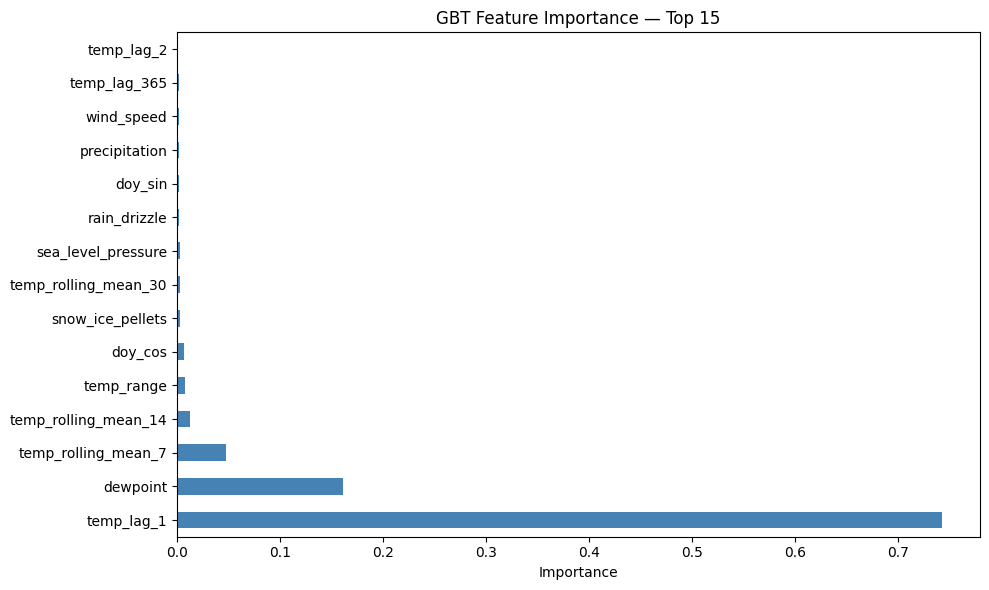


💡 Which features dominate? Lag features? Cyclical? Rolling stats?
   This tells you what temporal patterns the model is using.


In [35]:
# Feature importance — which temporal features matter most?
importances = pd.Series(gbt.feature_importances_, index=FEATURE_COLS)
top_features = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_features.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("GBT Feature Importance — Top 15")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("\n💡 Which features dominate? Lag features? Cyclical? Rolling stats?")
print("   This tells you what temporal patterns the model is using.")

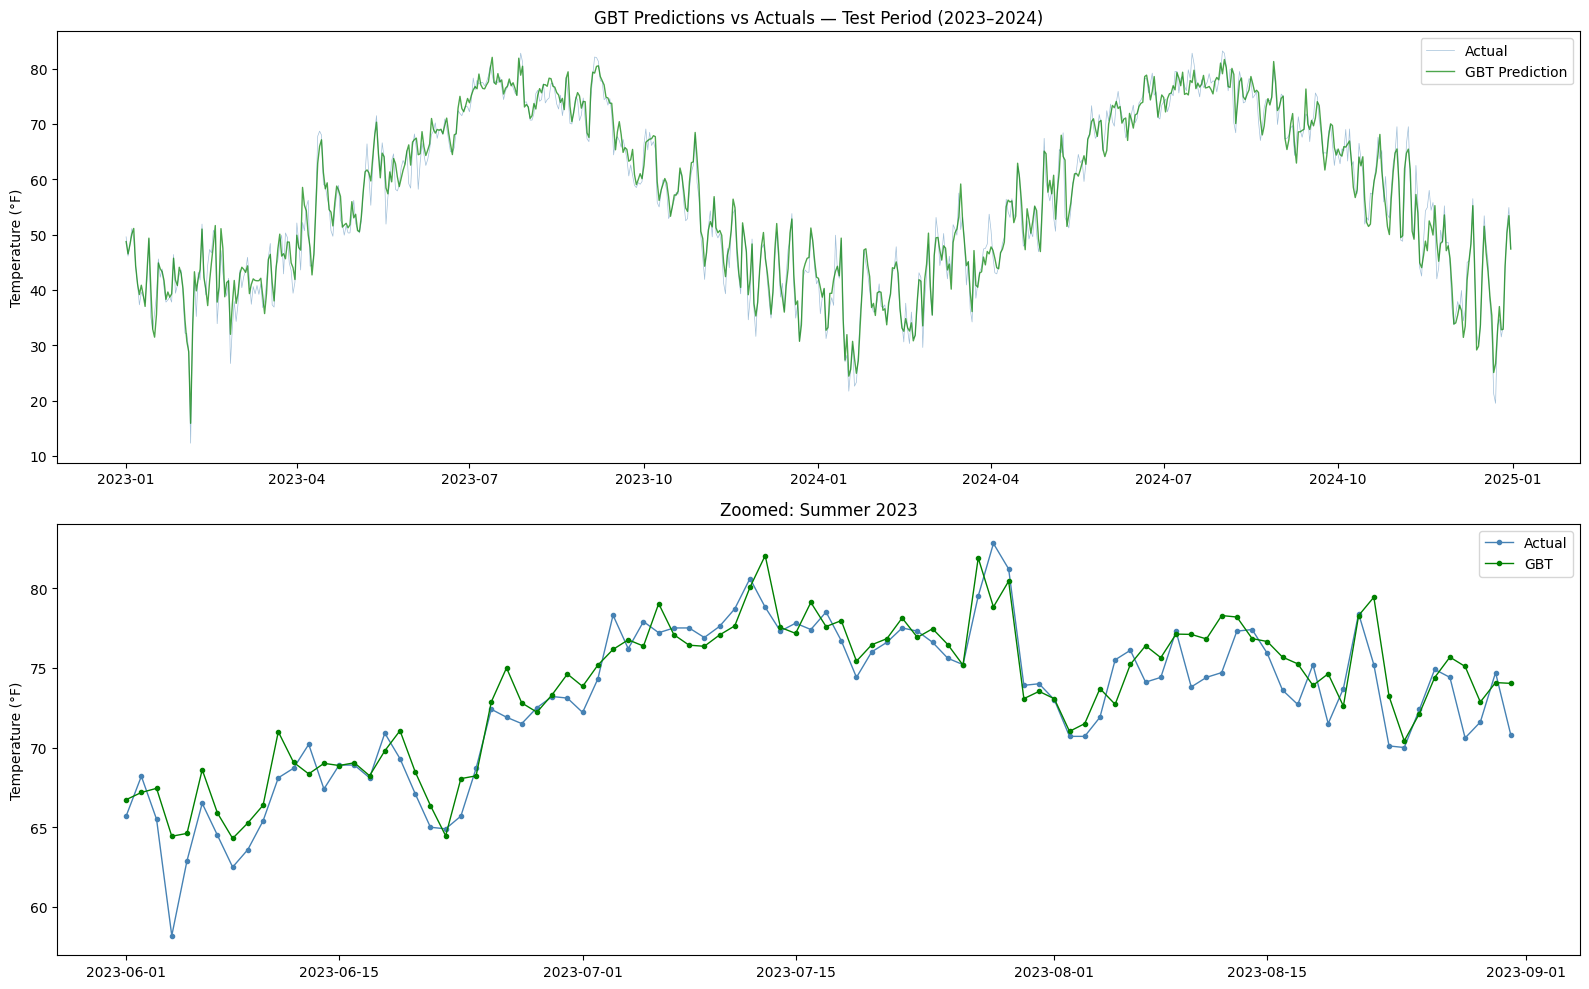

In [36]:
# Visualize GBT predictions vs actuals
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Full test period
axes[0].plot(df_test.index, y_test, color="steelblue", alpha=0.5, linewidth=0.5, label="Actual")
axes[0].plot(df_test.index, y_test_pred, color="green", alpha=0.7, linewidth=1, label="GBT Prediction")
axes[0].set_title("GBT Predictions vs Actuals — Test Period (2023–2024)")
axes[0].set_ylabel("Temperature (°F)")
axes[0].legend()

# Zoomed: same summer window as ARIMA for comparison
zoom_idx = (df_test.index >= "2023-06-01") & (df_test.index <= "2023-08-31")
axes[1].plot(df_test.index[zoom_idx], y_test[zoom_idx], "o-", color="steelblue",
             markersize=3, linewidth=1, label="Actual")
axes[1].plot(df_test.index[zoom_idx], y_test_pred[zoom_idx], "o-", color="green",
             markersize=3, linewidth=1, label="GBT")
axes[1].set_title("Zoomed: Summer 2023")
axes[1].set_ylabel("Temperature (°F)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3.3 — Write Training Script for Vertex AI

In [37]:
%%writefile lab9_gbt_train.py
"""
Lab 9 — GBT Training Script for Vertex AI
Trains a GradientBoostingRegressor on JFK temperature data with temporal features.
"""
import argparse
import os
import json
import joblib
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from google.cloud import storage, aiplatform

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-uri", type=str, required=True, help="GCS path to data folder")
    parser.add_argument("--model-uri", type=str, required=True, help="GCS path for model output")
    parser.add_argument("--n-estimators", type=int, default=500)
    parser.add_argument("--max-depth", type=int, default=5)
    parser.add_argument("--learning-rate", type=float, default=0.05)
    parser.add_argument("--min-samples-split", type=int, default=10)
    parser.add_argument("--subsample", type=float, default=0.8)
    return parser.parse_args()

def load_data(data_uri):
    """Load train/val/test CSVs from GCS."""
    dfs = {}
    for split in ["train", "val", "test"]:
        path = f"{data_uri}/jfk_weather_{split}.csv"
        dfs[split] = pd.read_csv(path)
        print(f"  Loaded {split}: {len(dfs[split])} rows")
    return dfs["train"], dfs["val"], dfs["test"]

def get_feature_cols(df):
    """Select feature columns (exclude target and raw date/calendar)."""
    exclude = ["date", "temp", "temp_max", "temp_min", "year", "month", "day",
               "day_of_week", "day_of_year", "week_of_year"]
    return [c for c in df.columns if c not in exclude]

def main():
    args = parse_args()
    print(f"\n{'='*60}")
    print(f"Lab 9 — GBT Training")
    print(f"{'='*60}")
    print(f"  n_estimators: {args.n_estimators}")
    print(f"  max_depth: {args.max_depth}")
    print(f"  learning_rate: {args.learning_rate}")
    print(f"  subsample: {args.subsample}")
    
    # Load data
    print("\n📂 Loading data...")
    df_train, df_val, df_test = load_data(args.data_uri)
    
    feature_cols = get_feature_cols(df_train)
    print(f"  Features: {len(feature_cols)}")
    
    X_train = df_train[feature_cols].values
    y_train = df_train["temp"].values
    X_val = df_val[feature_cols].values
    y_val = df_val["temp"].values
    X_test = df_test[feature_cols].values
    y_test = df_test["temp"].values
    
    # Train
    print("\n🏋️ Training...")
    model = GradientBoostingRegressor(
        n_estimators=args.n_estimators,
        max_depth=args.max_depth,
        learning_rate=args.learning_rate,
        min_samples_split=args.min_samples_split,
        subsample=args.subsample,
        min_samples_leaf=5,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Evaluate
    results = {}
    for name, X, y in [("val", X_val, y_val), ("test", X_test, y_test)]:
        preds = model.predict(X)
        rmse = float(np.sqrt(mean_squared_error(y, preds)))
        mae = float(mean_absolute_error(y, preds))
        mape = float(np.mean(np.abs((y - preds) / y)) * 100)
        results[name] = {"rmse": rmse, "mae": mae, "mape": mape}
        print(f"\n📊 {name.upper()}: RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.1f}%")
    
    # Save model
    local_model_path = "/tmp/model.joblib"
    joblib.dump(model, local_model_path)
    
    # Upload to GCS
    gcs_model_path = args.model_uri.replace("gs://", "")
    bucket_name = gcs_model_path.split("/")[0]
    blob_path = "/".join(gcs_model_path.split("/")[1:]) + "/model.joblib"
    
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(blob_path)
    blob.upload_from_filename(local_model_path)
    print(f"\n✅ Model saved to gs://{bucket_name}/{blob_path}")
    
    # Save metrics
    metrics_path = "/".join(gcs_model_path.split("/")[1:]) + "/metrics.json"
    blob_metrics = bucket.blob(metrics_path)
    blob_metrics.upload_from_string(json.dumps(results, indent=2))
    print(f"✅ Metrics saved to gs://{bucket_name}/{metrics_path}")
    
    # Save feature names
    features_path = "/".join(gcs_model_path.split("/")[1:]) + "/feature_cols.json"
    blob_features = bucket.blob(features_path)
    blob_features.upload_from_string(json.dumps(feature_cols))
    print(f"✅ Feature columns saved to gs://{bucket_name}/{features_path}")

if __name__ == "__main__":
    main()


Overwriting lab9_gbt_train.py


## 3.4 — Submit GBT Training to Vertex AI

In [38]:
!gcloud container images list --repository=us-docker.pkg.dev/vertex-ai/training

NAME
us-docker.pkg.dev/vertex-ai/training/cvr
us-docker.pkg.dev/vertex-ai/training/cvr2
us-docker.pkg.dev/vertex-ai/training/pytorch-cpu.1-4
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.1-10
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.1-11
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.1-12
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.1-12.py310
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.1-13
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.1-13.py310
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.1-4
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.1-6
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.1-7
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.1-9
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.2-0.py310
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.2-1.py310
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.2-2.py310
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.2-3.py310
us-docker.pkg.dev/vertex-ai/training/pytorch-gpu.2-4.py310
us-docker.pkg.de

In [40]:
from datetime import datetime

TIMESTAMP = datetime.now().strftime("%Y%m%d-%H%M%S")
GBT_MODEL_URI = f"{MODEL_URI}/gbt-{TIMESTAMP}"

job = aiplatform.CustomTrainingJob(
    display_name=f"lab9-gbt-{TIMESTAMP}",
    script_path="lab9_gbt_train.py",
    container_uri="us-docker.pkg.dev/vertex-ai/training/sklearn-cpu.1-0:latest",
    requirements=["google-cloud-storage"],
)

print(f"⏳ Submitting GBT training job to Vertex AI...")
print(f"   Model output: {GBT_MODEL_URI}")

job.run(
    args=[
        f"--data-uri={DATA_URI}",
        f"--model-uri={GBT_MODEL_URI}",
        "--n-estimators=500",
        "--max-depth=5",
        "--learning-rate=0.05",
        "--subsample=0.8",
    ],
    replica_count=1,
    machine_type="n1-standard-4",
)

print("\n✅ GBT training job complete!")

⏳ Submitting GBT training job to Vertex AI...
   Model output: gs://carty-470812-time-series/lab9-timeseries/models/gbt-20260306-101920
Training script copied to:
gs://carty-470812-time-series/aiplatform-2026-03-06-10:19:20.306-aiplatform_custom_trainer_script-0.1.tar.gz.
Training Output directory:
gs://carty-470812-time-series/aiplatform-custom-training-2026-03-06-10:19:20.456 
View Training:
https://console.cloud.google.com/ai/platform/locations/us-central1/training/8410454832187441152?project=873708835509
CustomTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/8410454832187441152 current state:
3
View backing custom job:
https://console.cloud.google.com/ai/platform/locations/us-central1/training/8022441370633371648?project=873708835509
CustomTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/8410454832187441152 current state:
3
CustomTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/8410454832187441152 current st

In [41]:
# Log GBT results to Vertex AI Experiments
experiment_name = f"lab9-timeseries-{TIMESTAMP}"

aiplatform.init(experiment=experiment_name)

# Load metrics from GCS
import json
bucket = storage_client.bucket(BUCKET_NAME)
metrics_blob = bucket.blob(f"{LAB9_PREFIX}/models/gbt-{TIMESTAMP}/metrics.json")
gbt_metrics = json.loads(metrics_blob.download_as_string())

with aiplatform.start_run("gbt-run") as run:
    run.log_params({
        "model_type": "GradientBoostingRegressor",
        "n_estimators": 500,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "num_features": len(FEATURE_COLS),
    })
    run.log_metrics({
        "val_rmse": gbt_metrics["val"]["rmse"],
        "val_mae": gbt_metrics["val"]["mae"],
        "val_mape": gbt_metrics["val"]["mape"],
        "test_rmse": gbt_metrics["test"]["rmse"],
        "test_mae": gbt_metrics["test"]["mae"],
        "test_mape": gbt_metrics["test"]["mape"],
    })
    print("✅ GBT metrics logged to Experiments")
    print(f"   Val  RMSE: {gbt_metrics['val']['rmse']:.2f}")
    print(f"   Test RMSE: {gbt_metrics['test']['rmse']:.2f}")

Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/lab9-timeseries-20260306-101920-gbt-run to Experiment: lab9-timeseries-20260306-101920


✅ GBT metrics logged to Experiments
   Val  RMSE: 2.45
   Test RMSE: 2.36


---

**Part 3 Complete!** ✅

**What you built:**
- Framed time series as tabular regression using engineered features
- Trained GBT locally for quick iteration
- Analyzed feature importance (which temporal features matter most?)
- Submitted training to Vertex AI with prebuilt sklearn container
- Logged results to Vertex AI Experiments

**Key takeaways:**
- Time series CAN be treated as tabular regression with proper feature engineering
- GBT often beats pure statistical models when you have rich external features
- Feature importance reveals which temporal patterns the model relies on
- This approach requires manual feature engineering — ARIMA_PLUS does it automatically

---

# Part 4: Custom Training — LSTM

## Why LSTM for Time Series?

LSTM (Long Short-Term Memory) is a type of recurrent neural network designed for sequential data. Unlike GBT which treats each day as an independent row, LSTM sees a **window of consecutive days** as a single input.

**Key concept — windowed input:**
- GBT input: one row of features per day → one prediction
- LSTM input: a sequence of N consecutive days → prediction for day N+1
- Example: [day1_temp, day2_temp, ..., day30_temp] → day31_temp

**When LSTM beats GBT:**
- Long-range temporal dependencies (e.g., patterns spanning months)
- Complex non-linear sequences
- When manual feature engineering can't capture the pattern

**When GBT beats LSTM:**
- Rich external features available
- Shorter training data
- Need interpretability (feature importance)

## 4.1 — Prepare Windowed Data for LSTM

In [43]:
# LSTM needs data in windows: use last WINDOW_SIZE days to predict next day
# We'll use a simpler feature set for LSTM — just temp and a few key features
# LSTM learns temporal patterns from the sequence itself, so we don't need
# lag/rolling features (those are "manual LSTM" via feature engineering)

WINDOW_SIZE = 30  # Use 30 days of history to predict next day

# Features for LSTM — simpler set (no lag/rolling since LSTM handles that)
LSTM_FEATURES = [
    "temp",
    "dewpoint",
    "wind_speed",
    "precipitation",
    "month_sin", "month_cos",
    "dow_sin", "dow_cos",
]

print(f"📋 LSTM features ({len(LSTM_FEATURES)}):")
for f in LSTM_FEATURES:
    print(f"   {f}")

# Check for NaN in selected features
for split_name, split_df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    nans = split_df[LSTM_FEATURES].isnull().sum().sum()
    print(f"\n  {split_name} NaN count: {nans}")

📋 LSTM features (8):
   temp
   dewpoint
   wind_speed
   precipitation
   month_sin
   month_cos
   dow_sin
   dow_cos

  train NaN count: 0

  val NaN count: 0

  test NaN count: 0


In [44]:
from sklearn.preprocessing import StandardScaler

# Normalize features (important for neural networks!)
scaler = StandardScaler()
scaler.fit(df_train[LSTM_FEATURES])

train_scaled = scaler.transform(df_train[LSTM_FEATURES])
val_scaled = scaler.transform(df_val[LSTM_FEATURES])
test_scaled = scaler.transform(df_test[LSTM_FEATURES])

print(f"✅ Scaler fitted on training data")
print(f"   Train mean (should be ~0): {train_scaled.mean(axis=0)[:3].round(4)}")
print(f"   Train std (should be ~1):  {train_scaled.std(axis=0)[:3].round(4)}")

# Save scaler parameters for the training script
scaler_params = {
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
    "feature_names": LSTM_FEATURES
}

✅ Scaler fitted on training data
   Train mean (should be ~0): [0. 0. 0.]
   Train std (should be ~1):  [1. 1. 1.]


In [45]:
def create_windows(data, window_size, target_col_idx=0):
    """
    Create sliding windows for LSTM.
    
    Input: array of shape (timesteps, features)
    Output: X of shape (samples, window_size, features), y of shape (samples,)
    
    target_col_idx: column index of the target variable (temp = 0)
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])  # Window of previous days
        y.append(data[i, target_col_idx])   # Next day's temp (scaled)
    return np.array(X), np.array(y)

# Create windows for each split
X_train_lstm, y_train_lstm = create_windows(train_scaled, WINDOW_SIZE)
X_val_lstm, y_val_lstm = create_windows(val_scaled, WINDOW_SIZE)
X_test_lstm, y_test_lstm = create_windows(test_scaled, WINDOW_SIZE)

print(f"📊 LSTM data shapes:")
print(f"   X_train: {X_train_lstm.shape} (samples, window, features)")
print(f"   y_train: {y_train_lstm.shape}")
print(f"   X_val:   {X_val_lstm.shape}")
print(f"   y_val:   {y_val_lstm.shape}")
print(f"   X_test:  {X_test_lstm.shape}")
print(f"   y_test:  {y_test_lstm.shape}")

print(f"\n💡 Each input is a {WINDOW_SIZE}-day window of {len(LSTM_FEATURES)} features")
print(f"   Each output is the next day's (scaled) temperature")

📊 LSTM data shapes:
   X_train: (7272, 30, 8) (samples, window, features)
   y_train: (7272,)
   X_val:   (700, 30, 8)
   y_val:   (700,)
   X_test:  (701, 30, 8)
   y_test:  (701,)

💡 Each input is a 30-day window of 8 features
   Each output is the next day's (scaled) temperature


## 4.2 — Write LSTM Training Script and Submit to Vertex AI

In [ ]:
%%writefile lab9_lstm_train.py
"""
Lab 9 — LSTM Training Script for Vertex AI
Trains a single-layer LSTM on JFK temperature data.
"""
import argparse
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from google.cloud import storage

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-uri", type=str, required=True)
    parser.add_argument("--model-uri", type=str, required=True)
    parser.add_argument("--window-size", type=int, default=14)
    parser.add_argument("--lstm-units", type=int, default=32)
    parser.add_argument("--epochs", type=int, default=30)
    parser.add_argument("--batch-size", type=int, default=256)
    parser.add_argument("--learning-rate", type=float, default=0.001)
    return parser.parse_args()

LSTM_FEATURES = [
    "temp", "dewpoint", "wind_speed", "precipitation",
    "month_sin", "month_cos", "dow_sin", "dow_cos",
]

def create_windows(data, window_size, target_col_idx=0):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
        y.append(data[i, target_col_idx])
    return np.array(X), np.array(y)

def main():
    args = parse_args()
    print(f"\n{'='*60}")
    print(f"Lab 9 — LSTM Training")
    print(f"{'='*60}")
    print(f"  window_size: {args.window_size}")
    print(f"  lstm_units: {args.lstm_units}")
    print(f"  epochs: {args.epochs}")
    print(f"  learning_rate: {args.learning_rate}")
    
    # Load data
    df_train = pd.read_csv(f"{args.data_uri}/jfk_weather_train.csv")
    df_val = pd.read_csv(f"{args.data_uri}/jfk_weather_val.csv")
    df_test = pd.read_csv(f"{args.data_uri}/jfk_weather_test.csv")
    print(f"  Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
    
    # Scale
    scaler = StandardScaler()
    scaler.fit(df_train[LSTM_FEATURES])
    train_scaled = scaler.transform(df_train[LSTM_FEATURES])
    val_scaled = scaler.transform(df_val[LSTM_FEATURES])
    test_scaled = scaler.transform(df_test[LSTM_FEATURES])
    
    # Create windows
    X_train, y_train = create_windows(train_scaled, args.window_size)
    X_val, y_val = create_windows(val_scaled, args.window_size)
    X_test, y_test = create_windows(test_scaled, args.window_size)
    print(f"  X_train: {X_train.shape}")
    
    # Build model
    model = keras.Sequential([
        layers.LSTM(args.lstm_units, input_shape=(args.window_size, len(LSTM_FEATURES))),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=args.learning_rate),
                  loss="mse", metrics=["mae"])
    
    # Train
    print("\n🏋️ Training...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=args.epochs,
        batch_size=args.batch_size,
        callbacks=[
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1),
        ],
        verbose=2
    )
    
    # Evaluate in °F
    def to_fahrenheit(scaled, scaler_obj):
        return scaled * scaler_obj.scale_[0] + scaler_obj.mean_[0]
    
    results = {}
    for name, X, y in [("val", X_val, y_val), ("test", X_test, y_test)]:
        preds = model.predict(X).flatten()
        actual_f = to_fahrenheit(y, scaler)
        pred_f = to_fahrenheit(preds, scaler)
        rmse = float(np.sqrt(mean_squared_error(actual_f, pred_f)))
        mae = float(mean_absolute_error(actual_f, pred_f))
        mape = float(np.mean(np.abs((actual_f - pred_f) / actual_f)) * 100)
        results[name] = {"rmse": rmse, "mae": mae, "mape": mape}
        print(f"\n📊 {name.upper()}: RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.1f}%")
    
    # Save model as SavedModel
    local_model_dir = "/tmp/lstm_model"
    model.save(local_model_dir)
    
    # Upload to GCS using gsutil (avoids blob permission issues)
    import subprocess
    gcs_model_dest = f"{args.model_uri}/saved_model/"
    subprocess.run(["gsutil", "-m", "cp", "-r", f"{local_model_dir}/*", gcs_model_dest], check=True)
    print(f"\n✅ SavedModel uploaded to {gcs_model_dest}")
    
    # Save metrics using gsutil too
    metrics_local = "/tmp/metrics.json"
    with open(metrics_local, "w") as f:
        json.dump(results, f, indent=2)
    subprocess.run(["gsutil", "cp", metrics_local, f"{args.model_uri}/metrics.json"], check=True)
    
    scaler_local = "/tmp/scaler.json"
    scaler_info = {"mean": scaler.mean_.tolist(), "scale": scaler.scale_.tolist(),
                   "features": LSTM_FEATURES}
    with open(scaler_local, "w") as f:
        json.dump(scaler_info, f, indent=2)
    subprocess.run(["gsutil", "cp", scaler_local, f"{args.model_uri}/scaler.json"], check=True)
    
    print(f"✅ Metrics and scaler saved")

if __name__ == "__main__":
    main()


Overwriting lab9_lstm_train.py


In [49]:
# Submit LSTM training to Vertex AI
from datetime import datetime
import json

TIMESTAMP = datetime.now().strftime("%Y%m%d-%H%M%S")
LSTM_MODEL_URI = f"{MODEL_URI}/lstm-{TIMESTAMP}"

# Upload script to GCS first
bucket = storage_client.bucket(BUCKET_NAME)
blob = bucket.blob(f"{LAB9_PREFIX}/scripts/lab9_lstm_train.py")
blob.upload_from_filename("lab9_lstm_train.py")
script_uri = f"gs://{BUCKET_NAME}/{LAB9_PREFIX}/scripts/lab9_lstm_train.py"

job = aiplatform.CustomJob(
    display_name=f"lab9-lstm-{TIMESTAMP}",
    worker_pool_specs=[
        {
            "machine_spec": {"machine_type": "n1-standard-4"},
            "replica_count": 1,
            "container_spec": {
                "image_uri": "us-docker.pkg.dev/vertex-ai/training/tf-cpu.2-15.py310:latest",
                "command": ["bash", "-c"],
                "args": [
                    f"pip install scikit-learn google-cloud-storage && "
                    f"gsutil cp {script_uri} train.py && "
                    f"python train.py "
                    f"--data-uri {DATA_URI} "
                    f"--model-uri {LSTM_MODEL_URI} "
                    f"--window-size 14 "
                    f"--lstm-units 32 "
                    f"--epochs 30 "
                    f"--batch-size 256 "
                    f"--learning-rate 0.001"
                ],
            },
        }
    ],
)

job.run(sync=True)

print("\n✅ LSTM training job complete!")

Creating CustomJob
CustomJob created. Resource name: projects/873708835509/locations/us-central1/customJobs/4021723383593959424
To use this CustomJob in another session:
custom_job = aiplatform.CustomJob.get('projects/873708835509/locations/us-central1/customJobs/4021723383593959424')
View Custom Job:
https://console.cloud.google.com/ai/platform/locations/us-central1/training/4021723383593959424?project=873708835509
CustomJob projects/873708835509/locations/us-central1/customJobs/4021723383593959424 current state:
2
CustomJob projects/873708835509/locations/us-central1/customJobs/4021723383593959424 current state:
2
CustomJob projects/873708835509/locations/us-central1/customJobs/4021723383593959424 current state:
2
CustomJob projects/873708835509/locations/us-central1/customJobs/4021723383593959424 current state:
2
CustomJob projects/873708835509/locations/us-central1/customJobs/4021723383593959424 current state:
2
CustomJob projects/873708835509/locations/us-central1/customJobs/40217

In [51]:
# Log LSTM results to Experiments
lstm_metrics_blob = bucket.blob(f"{LAB9_PREFIX}/models/lstm-{TIMESTAMP}/metrics.json")
lstm_metrics = json.loads(lstm_metrics_blob.download_as_string())

with aiplatform.start_run("lstm-run") as run:
    run.log_params({
        "model_type": "LSTM",
        "window_size": 14,
        "lstm_units": 32,
        "epochs": 30,
        "batch_size": 256,
        "learning_rate": 0.001,
        "num_features": len(LSTM_FEATURES),
    })
    run.log_metrics({
        "val_rmse": lstm_metrics["val"]["rmse"],
        "val_mae": lstm_metrics["val"]["mae"],
        "val_mape": lstm_metrics["val"]["mape"],
        "test_rmse": lstm_metrics["test"]["rmse"],
        "test_mae": lstm_metrics["test"]["mae"],
        "test_mape": lstm_metrics["test"]["mape"],
    })
    print("✅ LSTM metrics logged to Experiments")
    print(f"   Val  RMSE: {lstm_metrics['val']['rmse']:.2f}")
    print(f"   Test RMSE: {lstm_metrics['test']['rmse']:.2f}")

Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/lab9-timeseries-20260306-101920-lstm-run to Experiment: lab9-timeseries-20260306-101920


✅ LSTM metrics logged to Experiments
   Val  RMSE: 4.57
   Test RMSE: 3.95


---

**Part 4 Complete!** ✅

**What you built:**
- Prepared windowed data for LSTM (sliding window of 30 days → predict next day)
- Built and trained a single-layer LSTM with dropout
- Used EarlyStopping and ReduceLROnPlateau callbacks
- Submitted training to Vertex AI with prebuilt TF 2.15 container
- Logged results to Experiments alongside GBT

**Key takeaways:**
- LSTM sees sequences, GBT sees rows — different ways of representing temporal data
- StandardScaler is essential for neural networks (not for GBT)
- Windowed input means you lose the first WINDOW_SIZE days from each split
- LSTM doesn't need manual lag/rolling features — it learns temporal patterns from the sequence
- EarlyStopping prevents overfitting; ReduceLROnPlateau helps convergence

---

# Part 5: Comparison + ML.PREDICT + Metadata + Cleanup

## 5.1 — Compare All Three Models

In [52]:
# Collect all results for comparison
# ARIMA metrics (from Part 2)
arima_test = df_compare_arima.loc["2023-01-01":]
arima_test_rmse = np.sqrt(mean_squared_error(arima_test["actual_temp"], arima_test["predicted_temp"]))
arima_test_mae = mean_absolute_error(arima_test["actual_temp"], arima_test["predicted_temp"])
arima_test_mape = np.mean(np.abs(
    (arima_test["actual_temp"] - arima_test["predicted_temp"]) / arima_test["actual_temp"]
)) * 100

# GBT metrics (from Part 3 — Vertex AI run)
gbt_test_rmse = gbt_metrics["test"]["rmse"]
gbt_test_mae = gbt_metrics["test"]["mae"]
gbt_test_mape = gbt_metrics["test"]["mape"]

# LSTM metrics (from Part 4 — Vertex AI run)
lstm_test_rmse = lstm_metrics["test"]["rmse"]
lstm_test_mae = lstm_metrics["test"]["mae"]
lstm_test_mape = lstm_metrics["test"]["mape"]

# Build comparison table
comparison = pd.DataFrame({
    "Model": ["ARIMA_PLUS (BQML)", "Gradient Boosted Trees", "LSTM"],
    "Test RMSE (°F)": [arima_test_rmse, gbt_test_rmse, lstm_test_rmse],
    "Test MAE (°F)": [arima_test_mae, gbt_test_mae, lstm_test_mae],
    "Test MAPE (%)": [arima_test_mape, gbt_test_mape, lstm_test_mape],
    "Training Location": ["BigQuery", "Vertex AI", "Vertex AI"],
    "Container": ["None", "Prebuilt sklearn", "Prebuilt TF 2.15"],
    "Features Required": ["Just date + temp", f"{len(FEATURE_COLS)} engineered", f"{len(LSTM_FEATURES)} + windowing"],
    "Confidence Intervals": ["Yes (built-in)", "No", "No"],
    "Forecast Decomposition": ["Yes (ML.EXPLAIN)", "No", "No"],
})

print("="*80)
print("📊 MODEL COMPARISON — Lab 9 Time Series Forecasting")
print("="*80)
print(comparison.to_string(index=False))

📊 MODEL COMPARISON — Lab 9 Time Series Forecasting
                 Model  Test RMSE (°F)  Test MAE (°F)  Test MAPE (%) Training Location        Container Features Required Confidence Intervals Forecast Decomposition
     ARIMA_PLUS (BQML)        7.066138       5.458415      11.214841          BigQuery             None  Just date + temp       Yes (built-in)       Yes (ML.EXPLAIN)
Gradient Boosted Trees        2.358086       1.789751       3.522979         Vertex AI Prebuilt sklearn     28 engineered                   No                     No
                  LSTM        3.953731       3.048767       6.345181         Vertex AI Prebuilt TF 2.15     8 + windowing                   No                     No


In [53]:
# Log ARIMA metrics to Experiments too
with aiplatform.start_run("arima-plus-run") as run:
    run.log_params({
        "model_type": "ARIMA_PLUS",
        "platform": "BigQuery ML",
        "auto_arima": True,
        "data_frequency": "DAILY",
        "holiday_region": "US",
    })
    run.log_metrics({
        "test_rmse": float(arima_test_rmse),
        "test_mae": float(arima_test_mae),
        "test_mape": float(arima_test_mape),
    })
    print("✅ ARIMA_PLUS metrics logged to Experiments")

Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/lab9-timeseries-20260306-101920-arima-plus-run to Experiment: lab9-timeseries-20260306-101920


✅ ARIMA_PLUS metrics logged to Experiments


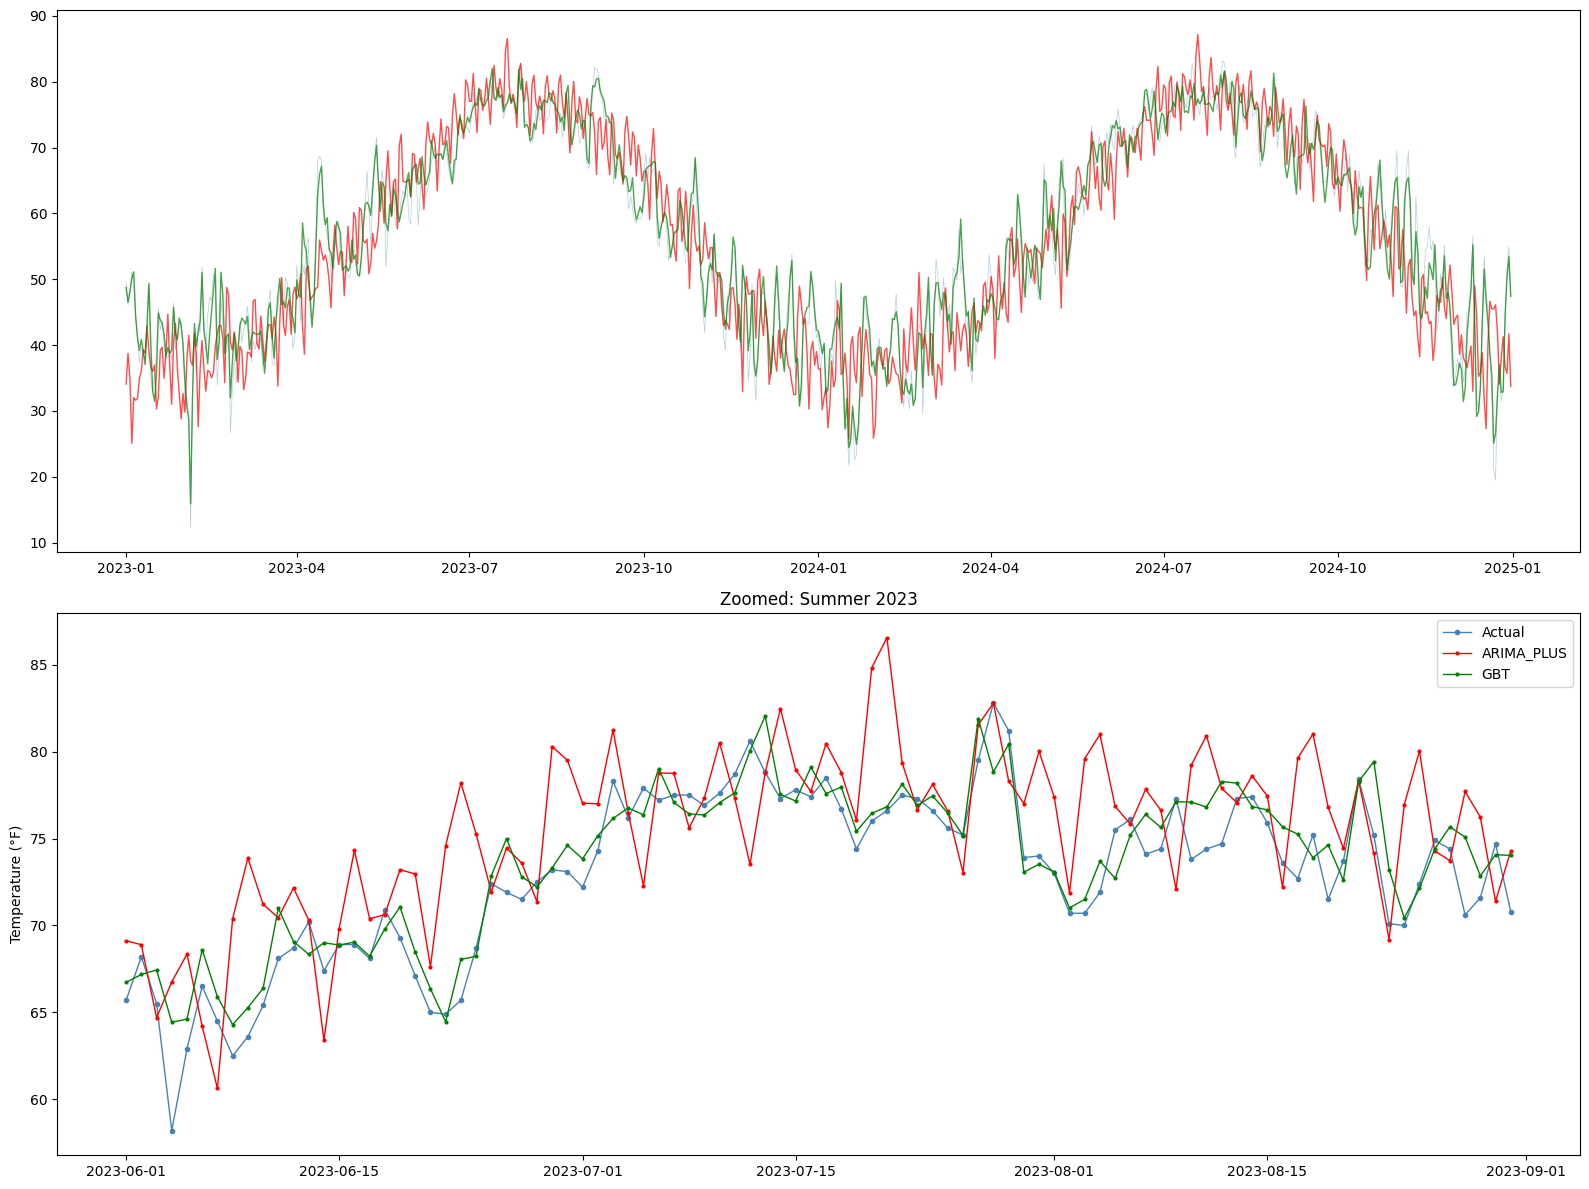

In [56]:
# Visualization: all three models on the same test period
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Full test period
axes[0].plot(df_test.index, y_test, color="steelblue", alpha=0.4, linewidth=0.5, label="Actual")

# ARIMA
arima_test_data = df_compare_arima.loc["2023-01-01":]
axes[0].plot(arima_test_data.index, arima_test_data["predicted_temp"],
             color="red", alpha=0.7, linewidth=1, label=f"ARIMA_PLUS (RMSE={arima_test_rmse:.1f})")

# GBT
axes[0].plot(df_test.index, y_test_pred,
             color="green", alpha=0.7, linewidth=1, label=f"GBT (RMSE={gbt_test_rmse:.1f})")

# LSTM (may not be available if local inference failed)
try:
    axes[0].plot(test_dates_lstm, y_test_pred_lstm,
                 color="purple", alpha=0.7, linewidth=1, label=f"LSTM (RMSE={lstm_test_rmse:.1f})")
except NameError:
    # No local predictions — just add to legend with metrics from Vertex AI
    axes[0].plot([], [], color="purple", linewidth=1, label=f"LSTM (RMSE={lstm_test_rmse:.1f}, no plot)")

# Zoomed: Summer 2023
zoom_start, zoom_end = "2023-06-01", "2023-08-31"

actual_zoom = df_test.loc[zoom_start:zoom_end]
axes[1].plot(actual_zoom.index, actual_zoom["temp"], "o-", color="steelblue",
             markersize=3, linewidth=1, label="Actual")

arima_zoom = arima_test_data.loc[zoom_start:zoom_end]
axes[1].plot(arima_zoom.index, arima_zoom["predicted_temp"], "o-", color="red",
             markersize=2, linewidth=1, label="ARIMA_PLUS")

gbt_zoom_mask = (df_test.index >= zoom_start) & (df_test.index <= zoom_end)
axes[1].plot(df_test.index[gbt_zoom_mask], y_test_pred[gbt_zoom_mask], "o-",
             color="green", markersize=2, linewidth=1, label="GBT")

try:
    lstm_zoom_mask = (test_dates_lstm >= zoom_start) & (test_dates_lstm <= zoom_end)
    axes[1].plot(test_dates_lstm[lstm_zoom_mask], y_test_pred_lstm[lstm_zoom_mask], "o-",
                color="purple", markersize=2, linewidth=1, label="LSTM")
except NameError:
    # No local predictions — just add to legend with metrics from Vertex AI
    axes[0].plot([], [], color="purple", linewidth=1, label=f"LSTM (RMSE={lstm_test_rmse:.1f}, no plot)")

axes[1].set_title("Zoomed: Summer 2023")
axes[1].set_ylabel("Temperature (°F)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5.2 — Batch Prediction with ML.PREDICT

ML.PREDICT lets you run batch predictions in BigQuery using the trained ARIMA_PLUS model. This is different from ML.FORECAST — it scores existing rows rather than generating future values.

**Exam relevance:** ML.PREDICT is the BQML way to do batch inference at scale. For 10TB+ datasets already in BigQuery, this is almost always the right answer (vs. exporting to Vertex AI).

In [57]:
# Use ML.PREDICT to score the test period data
# ML.PREDICT for ARIMA works on the historical data + generates fitted values
query_predict = f"""
SELECT
    date,
    temp AS actual_temp,
    predicted_temp.value AS predicted_temp
FROM
    ML.PREDICT(MODEL `{BQ_DATASET}.jfk_temp_arima`,
               (SELECT date, temp
                FROM `{BQ_DATASET}.jfk_daily_temp`
                WHERE date BETWEEN '2023-01-01' AND '2024-12-31'))
ORDER BY date
"""

try:
    df_ml_predict = bq_client.query(query_predict).to_dataframe()
    print(f"📊 ML.PREDICT results: {len(df_ml_predict)} rows")
    print(df_ml_predict.head(10).to_string(index=False))
    
    # Calculate metrics
    rmse_predict = np.sqrt(mean_squared_error(
        df_ml_predict["actual_temp"], df_ml_predict["predicted_temp"]))
    print(f"\n📊 ML.PREDICT RMSE: {rmse_predict:.2f} °F")
    print("\n💡 ML.PREDICT scores existing data. ML.FORECAST generates future data.")
    print("   Use ML.PREDICT for batch inference on historical data.")
    print("   Use ML.FORECAST for future predictions.")
except Exception as e:
    print(f"⚠️ ML.PREDICT note: {e}")
    print("\nML.PREDICT for ARIMA models may require specific column formats.")
    print("For ARIMA, ML.FORECAST is the primary prediction method.")
    print("ML.PREDICT is more commonly used with supervised BQML models (regression, classification).")

⚠️ ML.PREDICT note: 400 Invalid table-valued function ML.PREDICT
ARIMA model is unsupported in ml.predict. Please use ml.forecast instead. at [7:5]; reason: invalidQuery, location: query, message: Invalid table-valued function ML.PREDICT
ARIMA model is unsupported in ml.predict. Please use ml.forecast instead. at [7:5]

Location: US
Job ID: 4ad32a38-c3c4-4d40-9bae-f0010608798d


ML.PREDICT for ARIMA models may require specific column formats.
For ARIMA, ML.FORECAST is the primary prediction method.
ML.PREDICT is more commonly used with supervised BQML models (regression, classification).


## 5.3 — Metadata and Lineage

Track the full pipeline: NOAA data → BigQuery → GCS → training → models.

In [59]:
# Create execution to link dataset → models
# Use add_context_artifacts_and_executions instead, which goes through
# the experiment context (gRPC transport, avoids the REST/Python 3.13 bug)

from google.cloud.aiplatform_v1 import MetadataServiceClient
from google.cloud.aiplatform_v1.types import execution as execution_v1

# Create a metadata client explicitly with gRPC
api_endpoint = f"{REGION}-aiplatform.googleapis.com"
metadata_client = MetadataServiceClient(
    client_options={"api_endpoint": api_endpoint}
)

parent = f"projects/{PROJECT_ID}/locations/{REGION}/metadataStores/default"

# Create the execution via gRPC (not REST)
exec_resource = metadata_client.create_execution(
    parent=parent,
    execution=execution_v1.Execution(
        schema_title="system.ContainerExecution",
        display_name="lab9-training-pipeline",
        metadata={"description": "Lab 9: Train 3 time series models on JFK temperature data"},
    ),
)
print(f"✅ Execution created: {exec_resource.name}")

# Add events linking artifacts to execution
from google.cloud.aiplatform_v1.types import event as event_v1

for artifact, event_type in [
    (dataset_artifact, event_v1.Event.Type.INPUT),
    (arima_artifact, event_v1.Event.Type.OUTPUT),
    (gbt_artifact, event_v1.Event.Type.OUTPUT),
    (lstm_artifact, event_v1.Event.Type.OUTPUT),
]:
    metadata_client.add_execution_events(
        execution=exec_resource.name,
        events=[event_v1.Event(
            artifact=artifact.resource_name,
            type_=event_type,
        )],
    )

print("✅ Lineage linked: dataset → [ARIMA, GBT, LSTM]")

✅ Execution created: projects/873708835509/locations/us-central1/metadataStores/default/executions/105bf4de-165e-43aa-92b9-9a282adf4f01
✅ Lineage linked: dataset → [ARIMA, GBT, LSTM]


## 5.4 — Resource Cleanup

Delete all GCP resources created in this lab to avoid ongoing charges.

In [ ]:
# ── Cleanup ──────────────────────────────────────────────

print("🧹 Lab 9 Resource Cleanup")
print("="*60)

# 1. Delete BigQuery dataset (includes all tables and models)
try:
    bq_client.delete_dataset(
        f"{PROJECT_ID}.{BQ_DATASET}",
        delete_contents=True,
        not_found_ok=True
    )
    print(f"✅ Deleted BigQuery dataset: {BQ_DATASET}")
except Exception as e:
    print(f"⚠️ BQ dataset: {e}")

# 2. Delete GCS lab9 folder
blobs = list(storage_client.list_blobs(BUCKET_NAME, prefix=f"{LAB9_PREFIX}/"))
if blobs:
    for blob_item in blobs:
        blob_item.delete()
    print(f"✅ Deleted {len(blobs)} objects from gs://{BUCKET_NAME}/{LAB9_PREFIX}/")
else:
    print(f"✅ No GCS objects to delete in {LAB9_PREFIX}/")

# 3. Clean up Vertex AI Experiments
# Experiments persist but cost nothing — optional to delete
print(f"\nℹ️  Experiment '{experiment_name}' left in place (no cost)")
print("   Delete manually if desired: Console → Vertex AI → Experiments")

# 4. No endpoints deployed (batch only) — nothing to undeploy

print(f"\n{'='*60}")
print("✅ Lab 9 cleanup complete!")
print("   No ongoing charges from this lab.")

---

# Lab 9 Summary

## What You Built

| Component | Details |
|-----------|---------|
| **Dataset** | 25 years of JFK daily temperature from NOAA GSOD |
| **Feature Engineering** | Cyclical encoding, lag features, rolling stats, time-based split |
| **Model 1: ARIMA_PLUS** | Statistical forecasting in BigQuery ML (zero code) |
| **Model 2: GBT** | Tabular regression with temporal features on Vertex AI |
| **Model 3: LSTM** | Sequence model with windowed input on Vertex AI |
| **Batch Prediction** | ML.PREDICT in BigQuery |
| **Experiment Tracking** | All 3 models logged and compared |
| **Lineage** | Dataset → model chain tracked via Metadata |

## Key Exam Takeaways

1. **ARIMA_PLUS** is the answer when the scenario says "SQL user" + "time series" + "minimal effort"
2. **ML.FORECAST** generates future predictions; **ML.PREDICT** scores existing data
3. **ML.EXPLAIN_FORECAST** decomposes predictions (trend, seasonal, holiday) — unique to BQML
4. **Time-aware splitting** is mandatory for time series — random splits = data leakage
5. **Cyclical encoding** (sin/cos) for periodic features is a common exam topic
6. **GBT + feature engineering** can beat specialized models when you have rich external features
7. **LSTM** learns temporal patterns from sequences — doesn't need manual lag features
8. **Regression metrics**: RMSE (penalizes large errors), MAE (robust), MAPE (percentage-based)

## Decision Framework: Which Time Series Approach?

| Scenario | Best Approach |
|----------|---------------|
| SQL user, no ML expertise, quick forecast | ARIMA_PLUS |
| Rich external features, need interpretability | GBT with feature engineering |
| Complex sequential patterns, lots of data | LSTM / deep learning |
| Need confidence intervals out of the box | ARIMA_PLUS |
| Need forecast decomposition (trend/seasonal) | ARIMA_PLUS (ML.EXPLAIN_FORECAST) |
| Data already in BigQuery, minimal pipeline | ARIMA_PLUS + ML.PREDICT |

## Files Created

**GCS (deleted during cleanup):**
- `gs://{BUCKET_NAME}/lab9-timeseries/data/` — train/val/test CSVs
- `gs://{BUCKET_NAME}/lab9-timeseries/models/gbt-*/` — GBT model + metrics
- `gs://{BUCKET_NAME}/lab9-timeseries/models/lstm-*/` — LSTM SavedModel + metrics
- `gs://{BUCKET_NAME}/lab9-timeseries/scripts/` — training scripts

**BigQuery (deleted during cleanup):**
- `lab9_timeseries.jfk_daily_temp` — clean daily temperature
- `lab9_timeseries.jfk_daily_features` — full feature-engineered dataset
- `lab9_timeseries.jfk_temp_arima` — ARIMA_PLUS model

## Cost Estimate

| Component | Estimated Cost |
|-----------|---------------|
| BigQuery queries | ~$0.50 |
| BQML ARIMA_PLUS training | ~$0.10 |
| Vertex AI GBT training (n1-standard-4, ~10 min) | ~$0.04 |
| Vertex AI LSTM training (n1-standard-4, ~15 min) | ~$0.06 |
| GCS storage (temporary) | ~$0.01 |
| **Total** | **~$0.71** |